<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_10_strategy/stage_10_strategy_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_10 - Strategy design**

**Introducción**

En esta notebook se inicia el análisis operativo de los resultados OOS obtenidos con los modelos finales seleccionados. El objetivo no es volver a entrenar modelos ni ajustar hiperparámetros, sino estudiar cómo transformar las probabilidades generadas por los modelos en reglas de decisión y, posteriormente, en señales de trading.

El foco principal está en cubrir dos etapas del flujo de trabajo:

2. probabilidades → reglas de decisión
3. reglas de decisión → trades

Para esto, se trabajará con las probabilidades OOS generadas por los modelos finales, separando claramente el conjunto utilizado para diseño del conjunto reservado para validación final.

---

**Plan de trabajo**

1. Cargar entorno, librerías y rutas del proyecto.

2. Cargar datasets OOS de probabilidades y métricas.

3. Inspeccionar estructura de los datos:

   * modelos disponibles
   * splits
   * target
   * columnas

4. Seleccionar:

   * split de trabajo (valid)
   * modelos a analizar (GRU y Logistic Regression)

5. Construir dataset comparativo alineado muestra a muestra.

6. Análisis de probabilidades:

   * distribución
   * separación entre clases
   * correlación entre modelos

7. Definición de reglas base de decisión:

   * umbrales sobre probabilidades (long / short)
   * resolución de conflictos (long vs short)

8. Construcción de estrategias a partir de reglas:

   Se evaluarán distintas formas de convertir probabilidades en señales:

   * Estrategia individual por modelo:

     * GRU baseline
     * Logistic Regression baseline

   * Estrategias de combinación:

     * AND (ambos modelos deben coincidir)
     * OR / unión de señales
     * Ensemble por promedio de probabilidades
     * Estrategia híbrida (un modelo dominante + otro complementario)

9. Conversión de reglas en señales de trading:

   * señal ∈ {-1, 0, +1}
   * definición de trade

10. Evaluación de estrategias:

    * trade_rate
    * precision_useful
    * useful_rate_total

11. Selección de estrategia base.

12. Ajuste fino de reglas:

    * exploración de thresholds
    * análisis del trade-off entre volumen y precisión

# **1. Cargar entorno, librerías y rutas del proyecto**

## **1.1. Entorno**

In [7]:
# Permite anotaciones modernas en Python < 3.11
from __future__ import annotations

# ================================
# Standard library (mínimo necesario)
# ================================
import os
import sys
import warnings
import logging
from pathlib import Path

# ================================
# Third-party
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Configuración global
# ================================

# ---- Warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Logging limpio
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.propagate = False

if logger.handlers:
    logger.handlers.clear()

handler = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
handler.setFormatter(formatter)
logger.addHandler(handler)

logger.info("Environment initialized")

# ---- Pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# ---- Estilo plots
sns.set(style="whitegrid")

2026-04-27 19:31:22,799 | INFO | Environment initialized


## **1.2. Acceso a drive**

In [8]:
# ================================
# Entorno (Google Drive / local)
# ================================

from pathlib import Path
import os

# Detectar si estamos en Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DEFAULT_DRIVE_DIR = "/content/drive/MyDrive/neural_profit/"
else:
    # fallback local (puedes ajustarlo si quieres)
    DEFAULT_DRIVE_DIR = "./neural_profit/"

# Ruta base del proyecto
DRIVE_DIR = Path(os.environ.get("DRIVE_DIR", DEFAULT_DRIVE_DIR))

# Validación básica
if not DRIVE_DIR.exists():
    logger.warning(f"DRIVE_DIR no existe: {DRIVE_DIR}")
else:
    logger.info(f"DRIVE_DIR: {DRIVE_DIR}")

Mounted at /content/drive


2026-04-27 19:31:35,028 | INFO | DRIVE_DIR: /content/drive/MyDrive/neural_profit


## **1.3. Rutas de métricas y probabilidades**

In [9]:
# =========================================
# Base path
# =========================================
BEST_MODELS_DIR = Path("/content/drive/MyDrive/neural_profit/best_models")

# =========================================
# Paths de modelos
# =========================================
LR_FINAL_BALANCED_DIR = BEST_MODELS_DIR / os.environ.get(
    "LR_FINAL_BALANCED_DIR",
    "lr_final_balanced/"
)

GRU_FINAL_BASELINE_DIR = BEST_MODELS_DIR / os.environ.get(
    "GRU_FINAL_BASELINE_DIR",
    "gru_final_baseline/"
)



In [10]:
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# **2. Cargar datasets OOS de probabilidades y métricas.**

In [11]:
# =========================================================
# 4. Carga de datasets OOS (post modelo final)
# =========================================================

# Rutas relativas a BEST_MODELS_DIR
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# -------------------------------
# Validación de existencia
# -------------------------------
assert METRICS_OOS_DIR.exists(), f"No existe: {METRICS_OOS_DIR}"
assert PROBA_OOS_DIR.exists(), f"No existe: {PROBA_OOS_DIR}"

logger.info(f"Cargando métricas OOS desde: {METRICS_OOS_DIR}")
logger.info(f"Cargando probabilidades OOS desde: {PROBA_OOS_DIR}")

# -------------------------------
# Carga de datos
# -------------------------------
df_metrics_oos = pd.read_parquet(METRICS_OOS_DIR)
df_prob_oos = pd.read_parquet(PROBA_OOS_DIR)

# -------------------------------
# Inspección básica
# -------------------------------
print("=" * 80)
print("DATASETS OOS CARGADOS")
print("=" * 80)

print("df_metrics_oos:", df_metrics_oos.shape)
print("df_prob_oos   :", df_prob_oos.shape)

print("\nColumnas df_prob_oos:")
print(df_prob_oos.columns.tolist())

print("\nSplits disponibles:", df_prob_oos["split"].unique())
print("Targets disponibles:", df_prob_oos["target"].unique())
print("Modelos disponibles:", df_prob_oos["model"].unique())

print("=" * 80)

2026-04-27 19:31:35,882 | INFO | Cargando métricas OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_metrics_oos_valid_test.parquet
2026-04-27 19:31:35,884 | INFO | Cargando probabilidades OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_probabilities_oos_valid_test.parquet


DATASETS OOS CARGADOS
df_metrics_oos: (6, 34)
df_prob_oos   : (41385, 18)

Columnas df_prob_oos:
['proba_-1', 'proba_0', 'proba_1', 'pred_label', 'confidence', 'y_true', 'is_correct', 'signal_raw', 'trade', 'experiment_name', 'model', 'split', 'window_size', 'target', 'horizon', 'threshold_long', 'threshold_short', 'class_labels']

Splits disponibles: ['test' 'valid']
Targets disponibles: ['t2_p40_h30']
Modelos disponibles: ['gru' 'logistic_regression' 'xgboost']


# **3. Selección de datos OOS para diseño de estrategia**


En este paso se define el subconjunto de datos OOS que será utilizado para el diseño de la estrategia.

Se selecciona el split de validación, el target de interés y los modelos a analizar, con el fin de trabajar sobre un conjunto consistente y comparable.

Posteriormente, se realiza una inspección básica para verificar la estructura del dataset filtrado y asegurar que los datos estén correctamente preparados para los siguientes pasos del análisis.


In [12]:
# =========================================================
# 3. Selección de datos OOS para diseño de estrategia
# =========================================================

# -------------------------------
# Definición de scope de análisis
# -------------------------------

split_strategy = "valid"          # diseño sobre valid
target_strategy = "t2_p40_h30"    # target seleccionado

models_strategy = [
    "gru",
    "logistic_regression",
]

# -------------------------------
# Filtrado del dataset
# -------------------------------

df_strategy_valid = df_prob_oos[
    (df_prob_oos["split"] == split_strategy) &
    (df_prob_oos["target"] == target_strategy) &
    (df_prob_oos["model"].isin(models_strategy))
].copy()

# -------------------------------
# Inspección básica
# -------------------------------

print("=" * 80)
print("DATASET BASE PARA DISEÑO DE ESTRATEGIA")
print("=" * 80)

print(f"Split seleccionado : {split_strategy}")
print(f"Target seleccionado: {target_strategy}")
print(f"Modelos incluidos  : {models_strategy}")

print("-" * 80)

print("Shape total:", df_strategy_valid.shape)

print("\nDistribución por modelo:")
print(df_strategy_valid["model"].value_counts())

print("\nChequeo columnas clave:")
print(df_strategy_valid[[
    "model",
    "split",
    "target",
    "proba_-1",
    "proba_0",
    "proba_1",
    "y_true",
    "signal_raw",
    "trade"
]].head())

print("=" * 80)

DATASET BASE PARA DISEÑO DE ESTRATEGIA
Split seleccionado : valid
Target seleccionado: t2_p40_h30
Modelos incluidos  : ['gru', 'logistic_regression']
--------------------------------------------------------------------------------
Shape total: (13764, 18)

Distribución por modelo:
model
gru                    6882
logistic_regression    6882
Name: count, dtype: int64

Chequeo columnas clave:
     model  split      target  proba_-1   proba_0   proba_1  y_true  signal_raw  trade
6913   gru  valid  t2_p40_h30  0.224806  0.504271  0.270923       1           0  False
6914   gru  valid  t2_p40_h30  0.230340  0.502102  0.267557       1           0  False
6915   gru  valid  t2_p40_h30  0.236065  0.498919  0.265016       1           0  False
6916   gru  valid  t2_p40_h30  0.240946  0.497206  0.261848       1           0  False
6917   gru  valid  t2_p40_h30  0.241786  0.500210  0.258004       1           0  False


* Dataset correctamente filtrado: split `valid` y target único.
* Balance perfecto entre modelos: 6882 filas cada uno.
* Total esperado: 13764 → consistente (2 modelos × mismas muestras).
* Estructura de probabilidades correcta (`proba_-1`, `proba_0`, `proba_1`).
* Señales (`signal_raw`) y flags de trade presentes → listo para análisis operativo.
* Muestras aún separadas por modelo → falta alineación fila a fila (siguiente paso).


# **4. Separación GRU / Logistic Regression**

En este paso se separan las probabilidades por modelo, generando dos datasets independientes para GRU y Logistic Regression.

Luego, se verifica que ambos conjuntos estén correctamente alineados muestra a muestra, asegurando que contienen el mismo número de observaciones y las mismas etiquetas reales (y_true).

Esta validación es fundamental para poder comparar ambos modelos de forma consistente en los pasos siguientes.

In [13]:
# =========================================================
# 4. Separación GRU / Logistic Regression
# =========================================================

df_gru_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "gru"]
    .reset_index(drop=True)
    .copy()
)

df_lr_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "logistic_regression"]
    .reset_index(drop=True)
    .copy()
)

# Validación de alineación
assert len(df_gru_valid) == len(df_lr_valid), "GRU y LR no tienen la misma cantidad de muestras."

assert (df_gru_valid["y_true"].values == df_lr_valid["y_true"].values).all(), (
    "Las etiquetas y_true no están alineadas entre GRU y LR."
)

print("=" * 80)
print("VALIDACIÓN DE ALINEACIÓN")
print("=" * 80)
print(f"GRU valid: {df_gru_valid.shape}")
print(f"LR  valid: {df_lr_valid.shape}")
print("OK: GRU y LR están alineados muestra a muestra.")
print("=" * 80)

VALIDACIÓN DE ALINEACIÓN
GRU valid: (6882, 18)
LR  valid: (6882, 18)
OK: GRU y LR están alineados muestra a muestra.


# **5. Dataset comparativo GRU vs LR**

En este paso se construye un dataset comparativo que integra las salidas de ambos modelos en una única estructura.

Cada fila representa una misma observación, incluyendo las probabilidades, señales y decisiones de trading de GRU y Logistic Regression.

Esto permite analizar directamente el comportamiento de ambos modelos, comparar sus predicciones y estudiar cómo interactúan en términos operativos.

In [14]:
# =========================================================
# 5. Dataset comparativo GRU vs LR
# =========================================================

df_valid_cmp = pd.DataFrame({
    "y_true": df_gru_valid["y_true"].values,

    # Probabilidades GRU
    "gru_proba_-1": df_gru_valid["proba_-1"].values,
    "gru_proba_0":  df_gru_valid["proba_0"].values,
    "gru_proba_1":  df_gru_valid["proba_1"].values,
    "gru_pred_label": df_gru_valid["pred_label"].values,
    "gru_signal_raw": df_gru_valid["signal_raw"].values,
    "gru_trade": df_gru_valid["trade"].values,

    # Probabilidades LR
    "lr_proba_-1": df_lr_valid["proba_-1"].values,
    "lr_proba_0":  df_lr_valid["proba_0"].values,
    "lr_proba_1":  df_lr_valid["proba_1"].values,
    "lr_pred_label": df_lr_valid["pred_label"].values,
    "lr_signal_raw": df_lr_valid["signal_raw"].values,
    "lr_trade": df_lr_valid["trade"].values,
})

print("=" * 80)
print("DATASET COMPARATIVO VALID")
print("=" * 80)
print(df_valid_cmp.shape)
display(df_valid_cmp.head())

DATASET COMPARATIVO VALID
(6882, 13)


,y_true,gru_proba_-1,gru_proba_0,gru_proba_1,gru_pred_label,gru_signal_raw,gru_trade,lr_proba_-1,lr_proba_0,lr_proba_1,lr_pred_label,lr_signal_raw,lr_trade
0,1,0.224806,0.504271,0.270923,0,0,False,0.204912,0.537222,0.257866,0,0,False
1,1,0.230340,0.502102,0.267557,0,0,False,0.219718,0.490672,0.289610,0,0,False
2,1,0.236065,0.498919,0.265016,0,0,False,0.233783,0.471314,0.294903,0,0,False
3,1,0.240946,0.497206,0.261848,0,0,False,0.223747,0.484658,0.291594,0,0,False
4,1,0.241786,0.500210,0.258004,0,0,False,0.215719,0.515898,0.268383,0,0,False


* Dataset correctamente construido: una fila por observación, ambos modelos alineados.
* Dimensión consistente: 6882 muestras (valid completo).
* Probabilidades de ambos modelos presentes y comparables.
* Señales (`signal_raw`) y flags de trade incluidos para ambos modelos.
* Estructura lista para análisis de interacción y definición de reglas.
* No se observan inconsistencias en las primeras filas.


# **6. Análisis de actividad**

En este paso se analiza el comportamiento operativo de cada modelo a partir de las señales generadas.

Se evalúa la frecuencia de operación (trade_rate) y la precisión condicional, es decir, qué tan correctas son las predicciones cuando el modelo decide operar.

Además, se estudia la interacción entre ambos modelos, identificando en qué casos operan simultáneamente, de forma independiente o no operan.

Este análisis permite entender cómo se comportan los modelos en términos operativos y establece la base para definir y comparar futuras reglas de decisión.

In [15]:
# =========================================================
# 6.1. Actividad de cada modelo
# =========================================================

print("=" * 80)
print("ACTIVIDAD DE MODELOS")
print("=" * 80)

gru_trade_rate = df_valid_cmp["gru_trade"].mean()
lr_trade_rate  = df_valid_cmp["lr_trade"].mean()

print(f"GRU trade_rate: {gru_trade_rate:.4f}")
print(f"LR  trade_rate: {lr_trade_rate:.4f}")


# =========================================================
# 6.2. Precisión útil por modelo
# =========================================================

# GRU
df_gru_trades = df_valid_cmp[df_valid_cmp["gru_trade"]]

gru_precision = (df_gru_trades["gru_pred_label"] == df_gru_trades["y_true"]).mean()

# LR
df_lr_trades = df_valid_cmp[df_valid_cmp["lr_trade"]]

lr_precision = (df_lr_trades["lr_pred_label"] == df_lr_trades["y_true"]).mean()

print("=" * 80)
print("PRECISIÓN CONDICIONAL (CUANDO OPERAN)")
print("=" * 80)

print(f"GRU precision: {gru_precision:.4f}")
print(f"LR  precision: {lr_precision:.4f}")


# =========================================================
# 6.3. Interacción GRU vs LR
# =========================================================

df_valid_cmp["both_trade"] = df_valid_cmp["gru_trade"] & df_valid_cmp["lr_trade"]
df_valid_cmp["only_gru"]   = df_valid_cmp["gru_trade"] & (~df_valid_cmp["lr_trade"])
df_valid_cmp["only_lr"]    = df_valid_cmp["lr_trade"] & (~df_valid_cmp["gru_trade"])

print("=" * 80)
print("INTERACCIÓN DE SEÑALES")
print("=" * 80)

print("Ambos operan :", df_valid_cmp["both_trade"].sum())
print("Solo GRU     :", df_valid_cmp["only_gru"].sum())
print("Solo LR      :", df_valid_cmp["only_lr"].sum())


# =========================================================
# 6.4. Precisión por tipo de señal
# =========================================================

def precision_subset(df, pred_col):
    if len(df) == 0:
        return np.nan
    return (df[pred_col] == df["y_true"]).mean()

# Ambos operan → usamos GRU como referencia
df_both = df_valid_cmp[df_valid_cmp["both_trade"]]

# Solo GRU
df_only_gru = df_valid_cmp[df_valid_cmp["only_gru"]]

# Solo LR
df_only_lr = df_valid_cmp[df_valid_cmp["only_lr"]]

print("=" * 80)
print("PRECISIÓN POR ESCENARIO")
print("=" * 80)

print(f"Ambos (GRU ref): {precision_subset(df_both, 'gru_pred_label'):.4f}")
print(f"Solo GRU      : {precision_subset(df_only_gru, 'gru_pred_label'):.4f}")
print(f"Solo LR       : {precision_subset(df_only_lr, 'lr_pred_label'):.4f}")

ACTIVIDAD DE MODELOS
GRU trade_rate: 0.2457
LR  trade_rate: 0.1507
PRECISIÓN CONDICIONAL (CUANDO OPERAN)
GRU precision: 0.4530
LR  precision: 0.4744
INTERACCIÓN DE SEÑALES
Ambos operan : 712
Solo GRU     : 979
Solo LR      : 325
PRECISIÓN POR ESCENARIO
Ambos (GRU ref): 0.4452
Solo GRU      : 0.4586
Solo LR       : 0.4308


* GRU presenta mayor actividad: genera más señales y mayor cobertura del mercado.
* LR es más selectivo: menor `trade_rate`, pero mayor precisión cuando opera.
* La coincidencia entre modelos es limitada (712 casos) → no están fuertemente sincronizados.
* GRU aporta la mayor cantidad de señales exclusivas (979) → principal generador de oportunidades.
* LR aporta menos señales exclusivas (325) → rol más conservador.
* La precisión en coincidencias no mejora respecto a GRU solo → la confirmación (AND) no parece aportar valor.
* Las señales exclusivas de GRU mantienen buena precisión → contienen información útil.
* Las señales exclusivas de LR muestran menor precisión → menor aporte marginal.
* En conjunto, GRU aparece como el modelo dominante en generación de señales, mientras que LR no mejora claramente la calidad en intersección.


# **7. Análisis de distribución de probabilidades GRU vs LR**

En este paso se analiza la distribución de las probabilidades generadas por ambos modelos, con el objetivo de entender su comportamiento y calidad como señales de decisión.

Se estudian las distribuciones para posiciones long y short, su relación con la clase real, y cómo se diferencian entre casos en los que el modelo decide operar y aquellos en los que no.

Además, se evalúa la correlación entre los modelos para identificar el grado de redundancia o complementariedad entre sus predicciones.

Este análisis es fundamental para definir reglas de decisión basadas en probabilidades de forma consistente.

ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES


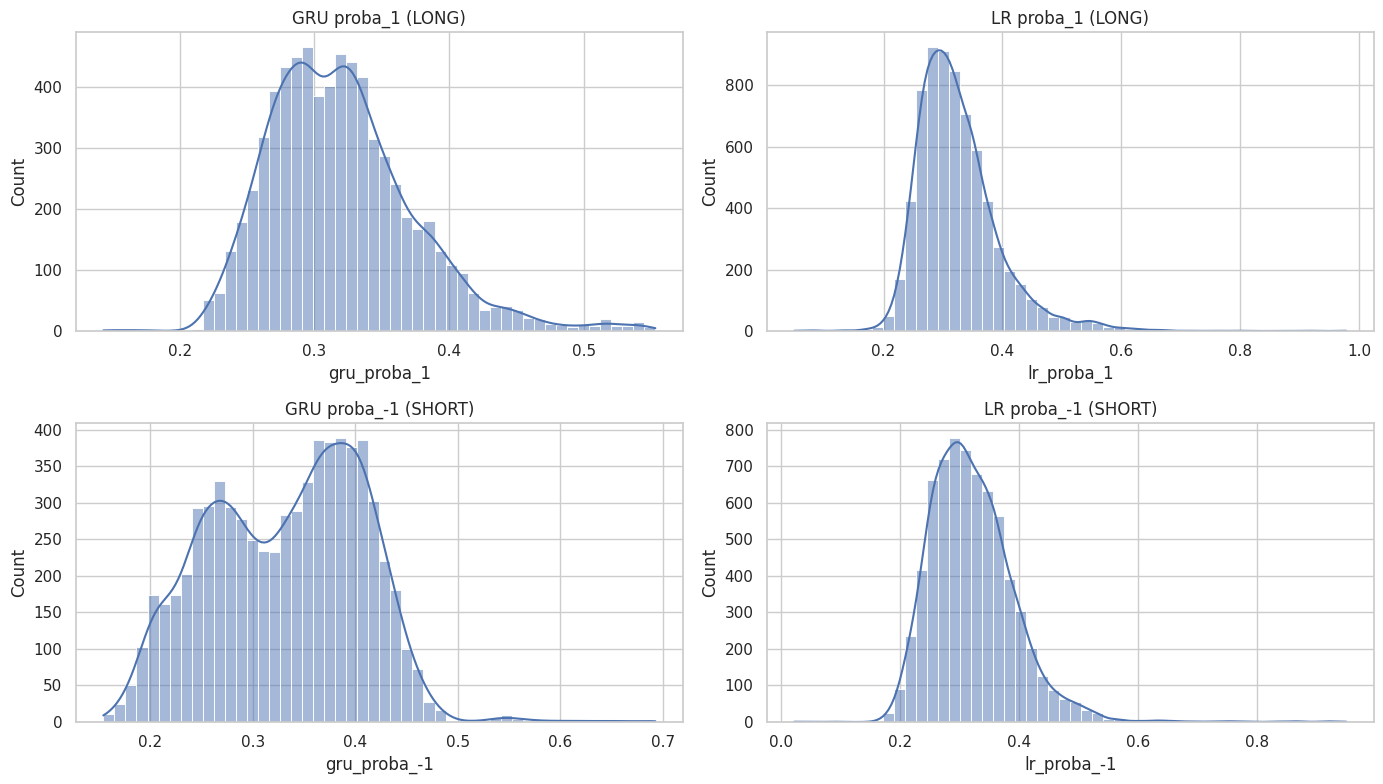

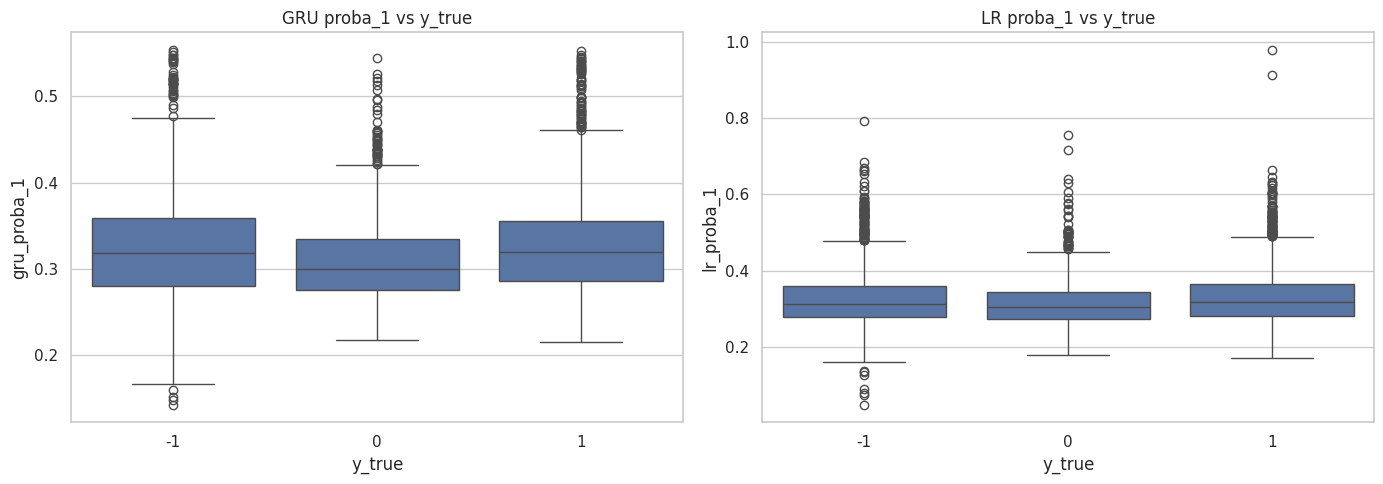

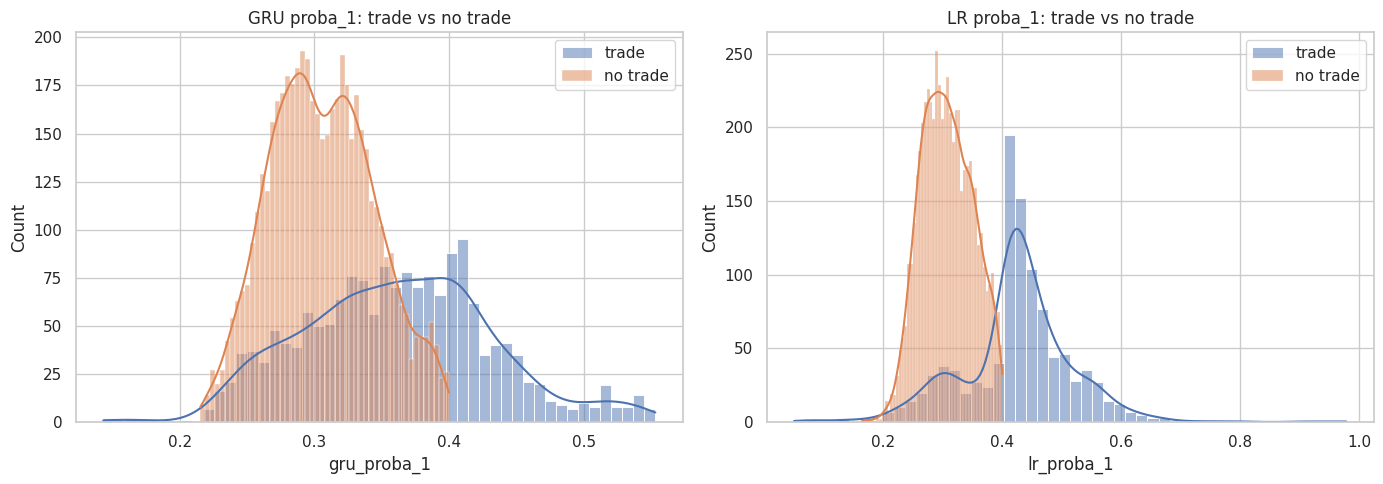

CORRELACIÓN ENTRE MODELOS
Corr LONG  (proba_1):  0.5735
Corr SHORT (proba_-1): 0.7086


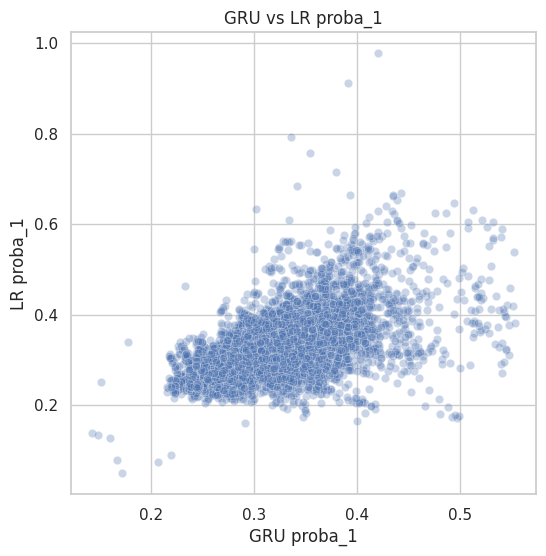

In [16]:
# =========================================================
# 7. Análisis de probabilidades GRU vs LR
# =========================================================

print("=" * 80)
print("ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES")
print("=" * 80)


# =========================================================
# 7.1. Histogramas de probabilidades long y short
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_valid_cmp["gru_proba_1"], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("GRU proba_1 (LONG)")

sns.histplot(df_valid_cmp["lr_proba_1"], bins=50, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("LR proba_1 (LONG)")

sns.histplot(df_valid_cmp["gru_proba_-1"], bins=50, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("GRU proba_-1 (SHORT)")

sns.histplot(df_valid_cmp["lr_proba_-1"], bins=50, ax=axes[1, 1], kde=True)
axes[1, 1].set_title("LR proba_-1 (SHORT)")

plt.tight_layout()
plt.show()


# =========================================================
# 7.2. Probabilidades vs clase real
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_valid_cmp, x="y_true", y="gru_proba_1", ax=axes[0])
axes[0].set_title("GRU proba_1 vs y_true")

sns.boxplot(data=df_valid_cmp, x="y_true", y="lr_proba_1", ax=axes[1])
axes[1].set_title("LR proba_1 vs y_true")

plt.tight_layout()
plt.show()


# =========================================================
# 7.3. Probabilidades en trades vs no trades
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df_valid_cmp[df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    label="trade",
    ax=axes[0],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    label="no trade",
    ax=axes[0],
    kde=True
)

axes[0].legend()
axes[0].set_title("GRU proba_1: trade vs no trade")

sns.histplot(
    df_valid_cmp[df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    label="trade",
    ax=axes[1],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    label="no trade",
    ax=axes[1],
    kde=True
)

axes[1].legend()
axes[1].set_title("LR proba_1: trade vs no trade")

plt.tight_layout()
plt.show()


# =========================================================
# 7.4. Correlación entre modelos
# =========================================================

corr_long = np.corrcoef(
    df_valid_cmp["gru_proba_1"],
    df_valid_cmp["lr_proba_1"]
)[0, 1]

corr_short = np.corrcoef(
    df_valid_cmp["gru_proba_-1"],
    df_valid_cmp["lr_proba_-1"]
)[0, 1]

print("=" * 80)
print("CORRELACIÓN ENTRE MODELOS")
print("=" * 80)
print(f"Corr LONG  (proba_1):  {corr_long:.4f}")
print(f"Corr SHORT (proba_-1): {corr_short:.4f}")


# =========================================================
# 7.5. Scatter plot GRU vs LR
# =========================================================

plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=df_valid_cmp["gru_proba_1"],
    y=df_valid_cmp["lr_proba_1"],
    alpha=0.3
)

plt.title("GRU vs LR proba_1")
plt.xlabel("GRU proba_1")
plt.ylabel("LR proba_1")
plt.show()

* GRU presenta probabilidades concentradas en un rango estrecho (≈ 0.28–0.38) → baja dispersión y menor nivel de confianza.

* LR muestra mayor dispersión y colas hacia valores altos → mejor capacidad de generar señales de alta confianza.

* La separación por clase (`y_true`) es débil en ambos modelos → fuerte solapamiento entre clases.

* LR presenta algunos valores extremos en clase 1 → potencial utilidad en zonas de alta probabilidad.

* En GRU, la distribución de *trade vs no trade* está bastante solapada → los thresholds actuales no separan claramente señal y ruido.

* En LR, los trades se concentran en probabilidades más altas → mejor comportamiento como filtro.

* Correlación moderada-alta:

  * LONG: 0.57
  * SHORT: 0.71

→ Los modelos comparten información relevante, especialmente en señales short.

* El scatter muestra relación positiva pero con dispersión → no son independientes, pero tampoco redundantes.

* Existe margen para combinación (ensemble), pero no se espera ganancia significativa vía confirmación estricta (AND).


# **8. Construcción y comparación de estrategias sobre VALID**

En este paso se construyen distintas reglas de decisión para transformar las probabilidades de los modelos en señales operativas.

Se comparan estrategias individuales y estrategias combinadas entre GRU y Logistic Regression, manteniendo el análisis sobre el split valid OOS.

El objetivo es evaluar qué esquema convierte mejor las probabilidades en trades útiles, considerando actividad, precisión condicional y proporción total de señales útiles.

In [17]:
# =========================================================
# 8. Construcción y comparación de estrategias sobre VALID
# =========================================================

# Copia de trabajo para construir señales de estrategia
df_strat = df_valid_cmp.copy()


# =========================================================
# 8.1. Función auxiliar para evaluar una estrategia
# =========================================================

def evaluate_strategy(df, signal_col, name):
    """
    Evalúa una estrategia basada en una señal operativa:
        1  = long
       -1  = short
        0  = no trade
    """

    signal = df[signal_col]
    y_true = df["y_true"]

    trade_mask = signal != 0
    n_obs = len(df)
    n_trades = trade_mask.sum()

    if n_trades == 0:
        n_useful = 0
        precision_useful = np.nan
    else:
        n_useful = (signal[trade_mask] == y_true[trade_mask]).sum()
        precision_useful = n_useful / n_trades

    trade_rate = n_trades / n_obs
    useful_rate_total = n_useful / n_obs

    return {
        "strategy": name,
        "n_obs": n_obs,
        "n_trades": n_trades,
        "trade_rate": trade_rate,
        "n_useful": n_useful,
        "precision_useful": precision_useful,
        "useful_rate_total": useful_rate_total,
    }


# =========================================================
# 8.2. Estrategia 1: GRU baseline
# =========================================================

# Usa directamente la señal generada por el modelo GRU
df_strat["signal_gru_baseline"] = df_strat["gru_signal_raw"]


# =========================================================
# 8.3. Estrategia 2: Logistic Regression baseline
# =========================================================

# Usa directamente la señal generada por Logistic Regression
df_strat["signal_lr_baseline"] = df_strat["lr_signal_raw"]


# =========================================================
# 8.4. Estrategia 3: Ensemble por promedio simple
# =========================================================

# Promedio de probabilidades long y short entre GRU y LR
df_strat["ens_score_long"] = (
    df_strat["gru_proba_1"] + df_strat["lr_proba_1"]
) / 2

df_strat["ens_score_short"] = (
    df_strat["gru_proba_-1"] + df_strat["lr_proba_-1"]
) / 2

# Umbrales iniciales del ensemble
thr_ens_long = 0.40
thr_ens_short = 0.40

# Señal inicial: 0 = no trade
df_strat["signal_ensemble_avg"] = 0

# Señal long
df_strat.loc[
    df_strat["ens_score_long"] >= thr_ens_long,
    "signal_ensemble_avg"
] = 1

# Señal short
df_strat.loc[
    df_strat["ens_score_short"] >= thr_ens_short,
    "signal_ensemble_avg"
] = -1

# Resolución de conflictos:
# si long y short superan threshold, se elige el score mayor
conflict_mask = (
    (df_strat["ens_score_long"] >= thr_ens_long) &
    (df_strat["ens_score_short"] >= thr_ens_short)
)

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] > df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_short"] > df_strat["ens_score_long"]),
    "signal_ensemble_avg"
] = -1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] == df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 0


# =========================================================
# 8.5. Estrategia 4: LR dominante + GRU complemento
# =========================================================

# Idea:
# - LR decide cuando tiene alta confianza.
# - Si LR no genera señal, GRU puede aportar una señal secundaria.
# - Se evita operar con GRU si LR contradice claramente la dirección.

thr_lr_long_main = 0.45
thr_lr_short_main = 0.45

thr_gru_long_secondary = 0.42
thr_gru_short_secondary = 0.42

# Señal inicial: 0 = no trade
df_strat["signal_lr_gru_hybrid"] = 0

# Señal principal por LR
df_strat.loc[
    df_strat["lr_proba_1"] >= thr_lr_long_main,
    "signal_lr_gru_hybrid"
] = 1

df_strat.loc[
    df_strat["lr_proba_-1"] >= thr_lr_short_main,
    "signal_lr_gru_hybrid"
] = -1

# GRU actúa solo si LR no decidió
no_signal_mask = df_strat["signal_lr_gru_hybrid"] == 0

# Señal long secundaria por GRU
df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_1"] >= thr_gru_long_secondary) &
    (df_strat["lr_proba_-1"] < thr_lr_short_main),
    "signal_lr_gru_hybrid"
] = 1

# Señal short secundaria por GRU
df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_-1"] >= thr_gru_short_secondary) &
    (df_strat["lr_proba_1"] < thr_lr_long_main),
    "signal_lr_gru_hybrid"
] = -1


# =========================================================
# 8.6. Evaluación comparativa de estrategias
# =========================================================

strategy_cols = {
    "GRU baseline": "signal_gru_baseline",
    "LR baseline": "signal_lr_baseline",
    "Ensemble avg": "signal_ensemble_avg",
    "LR dominant + GRU": "signal_lr_gru_hybrid",
}

results = []

for strategy_name, signal_col in strategy_cols.items():
    results.append(
        evaluate_strategy(
            df=df_strat,
            signal_col=signal_col,
            name=strategy_name,
        )
    )

df_strategy_results = pd.DataFrame(results)

df_strategy_results = df_strategy_results.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("COMPARACIÓN DE ESTRATEGIAS - VALID OOS")
print("=" * 80)

display(df_strategy_results)

COMPARACIÓN DE ESTRATEGIAS - VALID OOS


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total
0,LR baseline,6882,1037,0.150683,493,0.475410,0.071636
1,Ensemble avg,6882,1303,0.189334,612,0.469685,0.088928
2,GRU baseline,6882,1691,0.245713,783,0.463040,0.113775
3,LR dominant + GRU,6882,1221,0.177419,559,0.457821,0.081226


Gus, está bien encaminado, pero hay un punto importante: **no es opinión, es lectura correcta de los datos**. Lo que escribiste es consistente con los resultados.

Te hago un ajuste fino para que quede más sólido y riguroso.

---

Observaciones

* GRU presenta la mayor tasa de operación (0.2457), lo que implica mayor cobertura de oportunidades.
* Logistic Regression muestra la mayor precisión condicional (0.4754), pero con menor actividad.
* Ensemble logra un equilibrio intermedio entre volumen y precisión, pero no supera al GRU en utilidad total.
* La estrategia híbrida (LR dominante + GRU) no mejora el desempeño respecto a GRU baseline ni al ensemble.

---

Diagnóstico

1. Dominancia del GRU en términos operativos

* GRU maximiza `useful_rate_total`, que es la métrica más relevante desde el punto de vista operativo.
* A pesar de menor precisión, compensa con mayor volumen de señales útiles.

Esto indica que el modelo está capturando más oportunidades, aunque con mayor nivel de ruido.

---

2. Rol de Logistic Regression

* LR actúa como modelo más conservador, con mayor precisión pero menor frecuencia de operación.
* Su contribución principal está en la calidad de señales, no en la cantidad.

---

3. Limitaciones del ensemble

* El promedio de probabilidades mejora ligeramente la precisión respecto a GRU.
* Sin embargo, reduce el número de trades, lo que impacta negativamente en `useful_rate_total`.

No se observa una mejora neta en desempeño operativo.

---

4. Estrategia híbrida

* No logra capturar beneficios claros de ninguno de los dos modelos.
* Pierde tanto en volumen como en precisión relativa.

Puede descartarse como enfoque principal.

---

Conclusión

* El modelo GRU baseline constituye la mejor estrategia inicial bajo las reglas actuales.
* Las combinaciones evaluadas no logran mejorar simultáneamente volumen y calidad de señal.

---

Interpretación

* La señal del GRU es válida, pero está distribuida en rangos de probabilidad medios.
* El problema no es la capacidad predictiva del modelo, sino la forma en que se están utilizando sus probabilidades para generar decisiones.

---

**Siguiente paso**

* No es conveniente continuar explorando combinaciones entre modelos en esta etapa.
* El foco debe desplazarse hacia la calibración de thresholds del GRU.

Se propone:

* realizar un barrido sistemático de thresholds
* analizar el trade-off entre:

  * volumen de operaciones
  * precisión condicional
  * utilidad total

---

**Conclusión final (ajuste clave)**

> El problema no es el modelo, es la función de decisión.

Si mantenés eso claro, el resto del pipeline queda alineado.


# **9. Barrido de theresholds para GRU baseline**

En este paso se realiza un barrido sistemático de thresholds sobre las probabilidades del modelo GRU, con el objetivo de analizar cómo cambian las señales generadas en función de distintos niveles de decisión.

Se evalúa cada combinación de umbrales para posiciones long y short, midiendo su impacto en la frecuencia de operación, la precisión condicional y la proporción total de señales útiles.

Este análisis permite entender el trade-off entre volumen y calidad de señal, y constituye la base para definir una regla de decisión operativa más adecuada.

BARRIDO DE THRESHOLDS - GRU BASELINE


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,5321,0.773176,2226,0.418342,0.323452,0.30,0.30
1,GRU threshold grid,6882,5258,0.764022,2208,0.419932,0.320837,0.30,0.31
2,GRU threshold grid,6882,5057,0.734815,2195,0.434052,0.318948,0.30,0.34
3,GRU threshold grid,6882,5134,0.746004,2195,0.427542,0.318948,0.30,0.33
4,GRU threshold grid,6882,5198,0.755304,2190,0.421316,0.318221,0.30,0.32
5,GRU threshold grid,6882,4971,0.722319,2164,0.435325,0.314443,0.30,0.35
6,GRU threshold grid,6882,4884,0.709677,2127,0.435504,0.309067,0.30,0.36
7,GRU threshold grid,6882,5086,0.739029,2124,0.417617,0.308631,0.31,0.30
8,GRU threshold grid,6882,4999,0.726388,2098,0.419684,0.304853,0.31,0.31
9,GRU threshold grid,6882,4844,0.703865,2075,0.428365,0.301511,0.31,0.33


TOP CONFIGURACIONES CON trade_rate >= 0.05


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56
1,GRU threshold grid,6882,432,0.062772,230,0.532407,0.033421,0.41,0.54
2,GRU threshold grid,6882,423,0.061465,225,0.531915,0.032694,0.41,0.55
3,GRU threshold grid,6882,435,0.063208,229,0.526437,0.033275,0.41,0.53
4,GRU threshold grid,6882,436,0.063354,229,0.525229,0.033275,0.41,0.52
5,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.50
6,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.51
7,GRU threshold grid,6882,438,0.063644,228,0.520548,0.033130,0.41,0.49
8,GRU threshold grid,6882,346,0.050276,179,0.517341,0.026010,0.42,0.49
9,GRU threshold grid,6882,449,0.065243,231,0.514477,0.033566,0.41,0.48


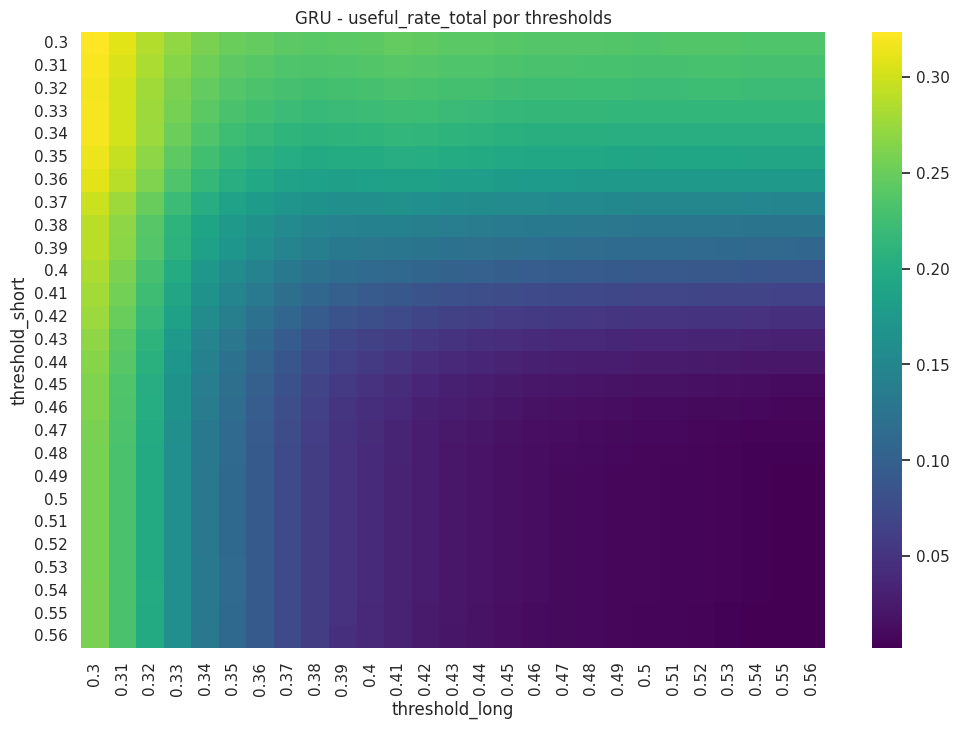

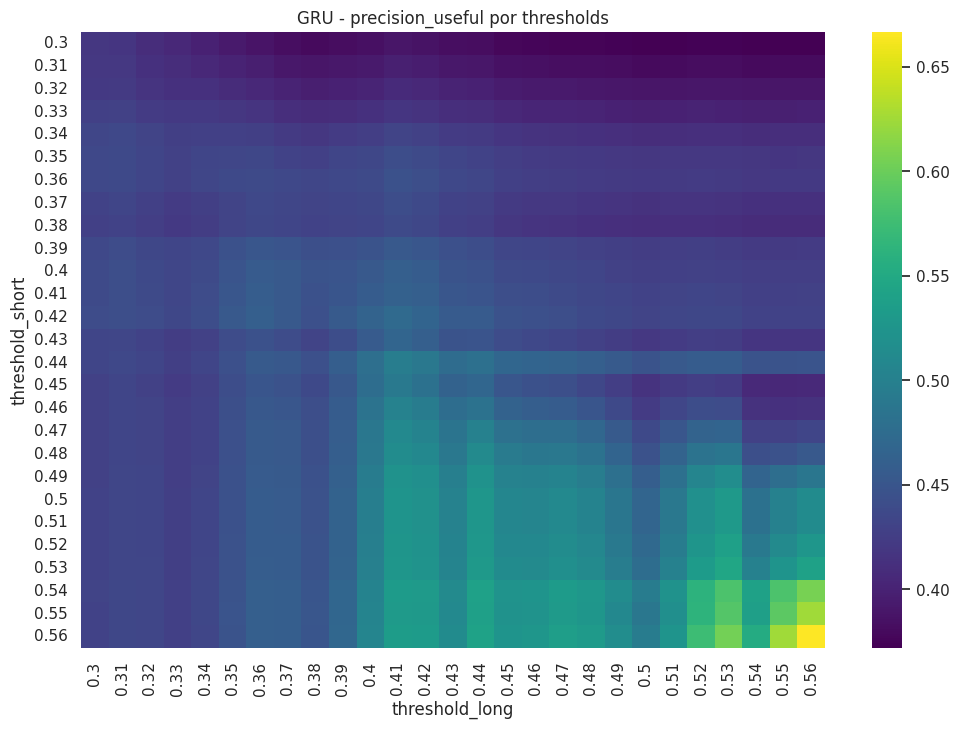

In [18]:
# =========================================================
# 9. Barrido de thresholds para GRU baseline
# =========================================================

df_gru_thr = df_strat.copy()


# =========================================================
# 9.1. Función para generar señales con thresholds variables
# =========================================================

def build_signal_from_thresholds(
    df: pd.DataFrame,
    proba_long_col: str,
    proba_short_col: str,
    threshold_long: float,
    threshold_short: float,
) -> np.ndarray:
    """
    Genera señales operativas:
        1  = long
       -1  = short
        0  = no trade

    Si long y short superan threshold al mismo tiempo,
    se elige la dirección con mayor probabilidad.
    """

    p_long = df[proba_long_col].values
    p_short = df[proba_short_col].values

    long_mask = p_long >= threshold_long
    short_mask = p_short >= threshold_short

    signal = np.zeros(len(df), dtype=int)

    # Casos sin conflicto
    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    # Casos con conflicto
    conflict_mask = long_mask & short_mask

    signal[conflict_mask & (p_long > p_short)] = 1
    signal[conflict_mask & (p_short > p_long)] = -1
    signal[conflict_mask & (p_long == p_short)] = 0

    return signal


# =========================================================
# 9.2. Definición del grid de thresholds
# =========================================================

# Rango de thresholds a evaluar para long y short
threshold_values = np.round(np.arange(0.30, 0.56, 0.01), 2)

results_thr = []

for thr_long in threshold_values:
    for thr_short in threshold_values:

        # Generar señal GRU usando la combinación actual de thresholds
        signal = build_signal_from_thresholds(
            df=df_gru_thr,
            proba_long_col="gru_proba_1",
            proba_short_col="gru_proba_-1",
            threshold_long=thr_long,
            threshold_short=thr_short,
        )

        # Copia temporal para evaluar la estrategia
        tmp = df_gru_thr.copy()
        tmp["signal_gru_thr"] = signal

        # Evaluar métricas operativas
        metrics = evaluate_strategy(
            df=tmp,
            signal_col="signal_gru_thr",
            name="GRU threshold grid",
        )

        # Registrar thresholds evaluados
        metrics["threshold_long"] = thr_long
        metrics["threshold_short"] = thr_short

        results_thr.append(metrics)


# Consolidar resultados del barrido
df_gru_threshold_grid = pd.DataFrame(results_thr)


# =========================================================
# 9.3. Ranking por useful_rate_total
# =========================================================

df_gru_threshold_grid = df_gru_threshold_grid.sort_values(
    by=["useful_rate_total", "precision_useful", "trade_rate"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("BARRIDO DE THRESHOLDS - GRU BASELINE")
print("=" * 80)

display(df_gru_threshold_grid.head(20))


# =========================================================
# 9.4. Ranking con filtro operativo mínimo
# =========================================================

# Filtro mínimo para evitar configuraciones con muy baja actividad
min_trade_rate = 0.05

df_gru_threshold_filtered = df_gru_threshold_grid[
    df_gru_threshold_grid["trade_rate"] >= min_trade_rate
].copy()

df_gru_threshold_filtered = df_gru_threshold_filtered.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print(f"TOP CONFIGURACIONES CON trade_rate >= {min_trade_rate}")
print("=" * 80)

display(df_gru_threshold_filtered.head(20))


# =========================================================
# 9.5. Heatmap de useful_rate_total
# =========================================================

heatmap_useful = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="useful_rate_total",
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_useful,
    cmap="viridis",
    annot=False
)

plt.title("GRU - useful_rate_total por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()


# =========================================================
# 9.6. Heatmap de precision_useful
# =========================================================

heatmap_precision = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="precision_useful",
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_precision,
    cmap="viridis",
    annot=False
)

plt.title("GRU - precision_useful por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()

## **Observaciones generales**



Cuando los thresholds son bajos (≈ 0.30):

* el modelo opera muy frecuentemente (más del 70% de las observaciones)
* el `useful_rate_total` alcanza sus valores máximos
* la precisión es relativamente baja (~0.42–0.43)

Esto implica alto volumen de operaciones, pero con mayor presencia de ruido.

---

A medida que aumentan los thresholds:

* disminuye significativamente el número de trades
* aumenta la precisión de las señales

Se observa un comportamiento más selectivo, con menor cantidad de operaciones pero de mayor calidad.

---

En thresholds altos (≈ 0.50 o superiores):

* la precisión supera el 0.50
* la tasa de operación cae a niveles bajos (~5–8%)
* el `useful_rate_total` disminuye considerablemente

Esto corresponde a un comportamiento excesivamente conservador, donde se pierden muchas oportunidades.

---

Lectura del heatmap

* La zona con mayor `useful_rate_total` se encuentra en thresholds bajos (0.30–0.35).
* La zona con mayor precisión se encuentra en thresholds altos (0.50–0.56).

Existe un trade-off claro entre volumen de operaciones y calidad de señal.

---

Insight principal

El modelo GRU presenta señal predictiva, pero esta se concentra en rangos de probabilidad intermedios (0.30–0.40), y no en valores extremos.

Como consecuencia:

* thresholds altos eliminan gran parte de las oportunidades
* thresholds bajos incorporan ruido en la toma de decisiones

---

Zona operativamente relevante

Los resultados sugieren que thresholds alrededor de:

* `threshold_long ≈ 0.40–0.42`
* `threshold_short ≈ 0.45–0.55`

permiten obtener:

* precisión cercana a 0.50
* `trade_rate` entre 0.06 y 0.08

Esto implica señales de mayor calidad, aunque con menor frecuencia.

---

Conclusión

* thresholds demasiado bajos generan exceso de ruido
* thresholds demasiado altos reducen excesivamente la actividad
* el baseline (0.40 / 0.40) se ubica en una zona razonable de compromiso entre volumen y calidad

---

Idea clave

El desempeño del modelo no es el problema principal.

El factor crítico es la definición de la regla de decisión, es decir, la selección de thresholds sobre las probabilidades.

---

Siguiente paso

Se recomienda definir un conjunto reducido de configuraciones candidatas de thresholds y compararlas directamente, en lugar de continuar con un barrido exhaustivo.

Este paso marca la transición desde el análisis hacia la definición de una estrategia operativa.


# **10. Selección y comparación de configuraciones candidatas**

En este paso se selecciona un conjunto reducido de configuraciones de thresholds a partir del análisis previo, con el objetivo de evaluarlas de forma directa y controlada.

Se busca comparar alternativas representativas del trade-off entre volumen y calidad de señal, permitiendo identificar configuraciones operativas viables sin depender de un barrido exhaustivo.

In [19]:
# =========================================================
# 10. Selección y comparación de configuraciones candidatas
# =========================================================

# =========================================================
# 10.1. Definición de configuraciones candidatas
# =========================================================

candidate_configs = [
    {
        "strategy": "GRU baseline",
        "threshold_long": 0.40,
        "threshold_short": 0.40,
        "description": "Configuración base utilizada hasta el momento",
    },
    {
        "strategy": "GRU balanced",
        "threshold_long": 0.40,
        "threshold_short": 0.45,
        "description": "Configuración levemente más conservadora en short",
    },
    {
        "strategy": "GRU conservative",
        "threshold_long": 0.41,
        "threshold_short": 0.50,
        "description": "Configuración orientada a mayor precisión",
    },
    {
        "strategy": "GRU high_precision",
        "threshold_long": 0.41,
        "threshold_short": 0.56,
        "description": "Configuración de máxima precisión observada en el grid",
    },
]


# =========================================================
# 10.2. Evaluación de configuraciones candidatas
# =========================================================

candidate_results = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_strat,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_strat.copy()
    tmp["signal_candidate"] = signal

    metrics = evaluate_strategy(
        df=tmp,
        signal_col="signal_candidate",
        name=config["strategy"],
    )

    metrics["threshold_long"] = config["threshold_long"]
    metrics["threshold_short"] = config["threshold_short"]
    metrics["description"] = config["description"]

    candidate_results.append(metrics)


df_candidate_results = pd.DataFrame(candidate_results)


# =========================================================
# 10.3. Ordenamiento de resultados
# =========================================================

df_candidate_results = df_candidate_results.sort_values(
    by=["useful_rate_total", "precision_useful"],
    ascending=False
).reset_index(drop=True)


# =========================================================
# 10.4. Visualización de resultados
# =========================================================

print("=" * 80)
print("COMPARACIÓN DE CONFIGURACIONES CANDIDATAS - GRU")
print("=" * 80)

display(df_candidate_results)

COMPARACIÓN DE CONFIGURACIONES CANDIDATAS - GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short,description
0,GRU baseline,6882,1691,0.245713,766,0.452986,0.111305,0.40,0.40,Configuración base utilizada hasta el momento
1,GRU balanced,6882,699,0.101569,333,0.476395,0.048387,0.40,0.45,Configuración levemente más conservadora en short
2,GRU conservative,6882,437,0.063499,229,0.524027,0.033275,0.41,0.50,Configuración orientada a mayor precisión
3,GRU high_precision,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56,Configuración de máxima precisión observada en...


* **GRU baseline** mantiene el mayor `useful_rate_total` con diferencia: 0.1113.
* **GRU balanced** mejora la precisión respecto al baseline, pero reduce mucho el volumen de trades.
* **GRU conservative** y **high_precision** logran precisión superior a 0.52, pero operan muy poco.
* El aumento de precisión no compensa la caída de actividad.
* Para una estrategia con flujo operativo, el **baseline sigue siendo la mejor configuración inicial**.
* Para una estrategia más selectiva, **GRU balanced** es la alternativa razonable.
* Las configuraciones `conservative` y `high_precision` quedan como referencias de alta precisión, pero no como estrategia principal.


# **11. Validación en TEST OOS**

En este paso se evalúan en test las configuraciones candidatas definidas previamente sobre valid.

El objetivo es verificar si las reglas de decisión mantienen un comportamiento estable fuera del conjunto utilizado para el diseño de la estrategia.

Para evitar sobreajuste, no se modifican thresholds ni reglas en esta etapa; simplemente se aplican las mismas configuraciones y se comparan sus métricas operativas.

In [20]:
# =========================================================
# 11. Validación en TEST OOS
# =========================================================

# =========================================================
# 11.1. Selección de datos TEST para GRU
# =========================================================

split_test = "test"

df_gru_test = df_prob_oos[
    (df_prob_oos["split"] == split_test) &
    (df_prob_oos["target"] == target_strategy) &
    (df_prob_oos["model"] == "gru")
].reset_index(drop=True).copy()

print("=" * 80)
print("DATASET TEST OOS - GRU")
print("=" * 80)
print(f"Shape: {df_gru_test.shape}")
print("=" * 80)


# =========================================================
# 11.2. Adaptación de columnas al formato usado en valid
# =========================================================

df_test_gru_cmp = pd.DataFrame({
    "y_true": df_gru_test["y_true"].values,
    "gru_proba_-1": df_gru_test["proba_-1"].values,
    "gru_proba_0":  df_gru_test["proba_0"].values,
    "gru_proba_1":  df_gru_test["proba_1"].values,
    "gru_pred_label": df_gru_test["pred_label"].values,
    "gru_signal_raw": df_gru_test["signal_raw"].values,
    "gru_trade": df_gru_test["trade"].values,
})


# =========================================================
# 11.3. Evaluación de configuraciones candidatas en TEST
# =========================================================

test_results = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_test_gru_cmp,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_test_gru_cmp.copy()
    tmp["signal_candidate"] = signal

    metrics = evaluate_strategy(
        df=tmp,
        signal_col="signal_candidate",
        name=config["strategy"],
    )

    metrics["split"] = "test"
    metrics["threshold_long"] = config["threshold_long"]
    metrics["threshold_short"] = config["threshold_short"]
    metrics["description"] = config["description"]

    test_results.append(metrics)

df_candidate_results_test = pd.DataFrame(test_results)


# =========================================================
# 11.4. Ordenamiento de resultados TEST
# =========================================================

df_candidate_results_test = df_candidate_results_test.sort_values(
    by=["useful_rate_total", "precision_useful"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("VALIDACIÓN TEST OOS - CONFIGURACIONES GRU")
print("=" * 80)

display(df_candidate_results_test)

DATASET TEST OOS - GRU
Shape: (6913, 18)
VALIDACIÓN TEST OOS - CONFIGURACIONES GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,split,threshold_long,threshold_short,description
0,GRU baseline,6913,916,0.132504,361,0.394105,0.052220,test,0.40,0.40,Configuración base utilizada hasta el momento
1,GRU balanced,6913,309,0.044698,137,0.443366,0.019818,test,0.40,0.45,Configuración levemente más conservadora en short
2,GRU conservative,6913,188,0.027195,72,0.382979,0.010415,test,0.41,0.50,Configuración orientada a mayor precisión
3,GRU high_precision,6913,188,0.027195,72,0.382979,0.010415,test,0.41,0.56,Configuración de máxima precisión observada en...


Observaciones:

* En `test`, todas las configuraciones degradan respecto a `valid`.
* **GRU baseline** sigue siendo la configuración con mayor `useful_rate_total`.
* **GRU balanced** mejora la precisión frente al baseline, pero opera muy poco.
* **GRU conservative** y **high_precision** pierden valor en test: baja actividad y baja precisión.
* Los thresholds más exigentes no generalizan bien.
* La mejor configuración operativa sigue siendo **GRU baseline (0.40 / 0.40)**, aunque con menor calidad OOS.
* El salto `valid → test` indica que antes del backtest conviene analizar estabilidad temporal y costos.


# **12. Evaluación operativa de las señales (PnL)**

En este paso se transforma la señal de trading en resultados económicos, con el objetivo de evaluar el desempeño real de la estrategia más allá de métricas de clasificación.

Se utilizan los retornos futuros asociados al horizonte del target para calcular el resultado de cada operación en función de la señal generada (long, short o no trade).

El análisis permite medir el comportamiento de la estrategia en términos de PnL, incorporando tanto la dirección de la predicción como la magnitud del movimiento del mercado.

De esta forma, se pasa de una evaluación basada en aciertos a una evaluación basada en resultados operativos, que es el criterio relevante para una estrategia de trading.


In [32]:
# =========================================================
# 12.1. Carga del dataset T2 completo para PnL
# =========================================================

print("=" * 80)
print("CARGA DATASET T2 COMPLETO PARA PnL")
print("=" * 80)

# ---------------------------------------------------------
# Ruta del dataset con precios, régimen, targets y delta_30
# ---------------------------------------------------------

IN_PARQUET_T2_FULL = DRIVE_DIR / Path(os.environ.get(
    "IN_PARQUET_T2_FULL",
    "data/04_features/mnq_t2.parquet"
))

# ---------------------------------------------------------
# Validación de existencia
# ---------------------------------------------------------

assert IN_PARQUET_T2_FULL.exists(), f"No existe: {IN_PARQUET_T2_FULL}"

# ---------------------------------------------------------
# Carga
# ---------------------------------------------------------

df_t2_full = pd.read_parquet(IN_PARQUET_T2_FULL)

print(f"Shape: {df_t2_full.shape}")

# ---------------------------------------------------------
# Validación de columnas necesarias
# ---------------------------------------------------------

required_cols = [
    "date",
    "close",
    "regime_id",
    "delta_30",
    "t2_p40_h30",
]

missing_cols = [col for col in required_cols if col not in df_t2_full.columns]

assert not missing_cols, f"Faltan columnas necesarias: {missing_cols}"

print("\nColumnas necesarias presentes:")
print(required_cols)

# ---------------------------------------------------------
# Inspección rápida de columnas relevantes
# ---------------------------------------------------------

keywords = ["date", "regime", "delta", "close", "t2"]

print("\nColumnas relevantes:")
for kw in keywords:
    cols = [c for c in df_t2_full.columns if kw.lower() in c.lower()]
    print(f"{kw}: {cols}")

print("=" * 80)

CARGA DATASET T2 COMPLETO PARA PnL
Shape: (88920, 22)

Columnas necesarias presentes:
['date', 'close', 'regime_id', 'delta_30', 't2_p40_h30']

Columnas relevantes:
date: ['date']
regime: ['regime_id']
delta: ['delta_30', 'delta_60']
close: ['close', 'close_fwd_30', 'close_fwd_60']
t2: ['t2_p40_h30', 't2_p40_h60', 't2_p50_h30']


In [38]:
# =========================================================
# 12.2. Alineación exacta por día para ventanas seq2one
# =========================================================

print("=" * 80)
print("VERIFICACIÓN DE ALINEACIÓN POR DÍA")
print("=" * 80)

L = 30
target_col = "t2_p40_h30"

# ---------------------------------------------------------
# 1. Ordenar igual que en el split original
# ---------------------------------------------------------

df_base = (
    df_t2_full
    .sort_values(["date", "minute_of_day"])
    .reset_index(drop=True)
    .copy()
)

df_base["_day"] = pd.to_datetime(df_base["date"]).dt.date

# ---------------------------------------------------------
# 2. Reconstruir split por días
# ---------------------------------------------------------

unique_days = pd.Index(sorted(df_base["_day"].unique()))

n_days = len(unique_days)
n_train_days = int(n_days * 0.70)
n_valid_days = int(n_days * 0.15)

train_days = set(unique_days[:n_train_days])
valid_days = set(unique_days[n_train_days:n_train_days + n_valid_days])
test_days  = set(unique_days[n_train_days + n_valid_days:])

df_valid_raw = df_base[df_base["_day"].isin(valid_days)].copy()
df_test_raw  = df_base[df_base["_day"].isin(test_days)].copy()

print(f"VALID raw rows: {len(df_valid_raw)}")
print(f"TEST raw rows : {len(df_test_raw)}")

# ---------------------------------------------------------
# 3. Aplicar lógica de ventanas por día
# ---------------------------------------------------------
# Para cada día, las primeras L-1 filas no generan ventana seq2one.
# Se conservan las filas desde la posición L-1 en adelante.

df_valid_aligned = (
    df_valid_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

df_test_aligned = (
    df_test_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

print("-" * 80)
print(f"VALID aligned rows: {len(df_valid_aligned)}")
print(f"df_valid_cmp rows : {len(df_valid_cmp)}")
print(f"TEST aligned rows : {len(df_test_aligned)}")
print(f"df_test_gru_cmp   : {len(df_test_gru_cmp)}")

assert len(df_valid_aligned) == len(df_valid_cmp), "VALID no alinea en cantidad."
assert len(df_test_aligned) == len(df_test_gru_cmp), "TEST no alinea en cantidad."

# ---------------------------------------------------------
# 4. Validar alineación real contra y_true
# ---------------------------------------------------------

valid_match = (
    df_valid_aligned[target_col].values == df_valid_cmp["y_true"].values
).mean()

test_match = (
    df_test_aligned[target_col].values == df_test_gru_cmp["y_true"].values
).mean()

print("-" * 80)
print(f"Match VALID y_true: {valid_match:.4f}")
print(f"Match TEST  y_true: {test_match:.4f}")

assert valid_match == 1.0, "VALID no alinea perfectamente."
assert test_match == 1.0, "TEST no alinea perfectamente."

print("-" * 80)
print("OK: alineación perfecta por día.")

# ---------------------------------------------------------
# 5. Agregar variables económicas
# ---------------------------------------------------------

df_valid_cmp["date"] = df_valid_aligned["date"].values
df_valid_cmp["minute_of_day"] = df_valid_aligned["minute_of_day"].values
df_valid_cmp["close"] = df_valid_aligned["close"].values
df_valid_cmp["delta_30"] = df_valid_aligned["delta_30"].values

df_test_gru_cmp["date"] = df_test_aligned["date"].values
df_test_gru_cmp["minute_of_day"] = df_test_aligned["minute_of_day"].values
df_test_gru_cmp["close"] = df_test_aligned["close"].values
df_test_gru_cmp["delta_30"] = df_test_aligned["delta_30"].values

print("Variables económicas agregadas correctamente.")
print("=" * 80)

VERIFICACIÓN DE ALINEACIÓN POR DÍA
VALID raw rows: 13320
TEST raw rows : 13380
--------------------------------------------------------------------------------
VALID aligned rows: 6882
df_valid_cmp rows : 6882
TEST aligned rows : 6913
df_test_gru_cmp   : 6913
--------------------------------------------------------------------------------
Match VALID y_true: 1.0000
Match TEST  y_true: 1.0000
--------------------------------------------------------------------------------
OK: alineación perfecta por día.
Variables económicas agregadas correctamente.


# **13. Cálculo de PnL por estrategia**

En este paso se transforma cada señal en un resultado económico utilizando delta_30.

Se evalúa el desempeño de las configuraciones del modelo GRU en términos de retorno por operación, retorno acumulado y métricas agregadas.

In [39]:
# =========================================================
# 13. Cálculo de PnL - GRU configuraciones
# =========================================================

print("=" * 80)
print("CÁLCULO DE PnL - GRU")
print("=" * 80)

# ---------------------------------------------------------
# 1. Función PnL
# ---------------------------------------------------------

def compute_pnl(df: pd.DataFrame, signal_col: str) -> pd.DataFrame:
    """
    PnL por operación:
        pnl = signal * delta_30
    """
    df = df.copy()
    df["pnl"] = df[signal_col] * df["delta_30"]
    df["cum_pnl"] = df["pnl"].cumsum()
    return df

# ---------------------------------------------------------
# 2. Construcción de señales (configuraciones GRU)
# ---------------------------------------------------------

def build_signal(df, thr_long, thr_short):
    p_long = df["gru_proba_1"].values
    p_short = df["gru_proba_-1"].values

    signal = np.zeros(len(df), dtype=int)

    long_mask = p_long >= thr_long
    short_mask = p_short >= thr_short

    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    conflict = long_mask & short_mask
    signal[conflict & (p_long > p_short)] = 1
    signal[conflict & (p_short > p_long)] = -1

    return signal

# ---------------------------------------------------------
# 3. Configuraciones a evaluar
# ---------------------------------------------------------

configs = [
    ("baseline", 0.40, 0.40),
    ("balanced", 0.40, 0.45),
    ("conservative", 0.41, 0.50),
    ("high_precision", 0.41, 0.56),
]

results = []

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal"] = build_signal(df_tmp, thr_l, thr_s)

    df_tmp = compute_pnl(df_tmp, "signal")

    trades = df_tmp[df_tmp["signal"] != 0]

    result = {
        "strategy": name,
        "n_trades": len(trades),
        "mean_pnl": trades["pnl"].mean(),
        "total_pnl": trades["pnl"].sum(),
        "win_rate": (trades["pnl"] > 0).mean(),
    }

    results.append(result)

df_pnl = pd.DataFrame(results).sort_values("total_pnl", ascending=False)

print("=" * 80)
print("RESULTADOS PnL")
print("=" * 80)

display(df_pnl)

CÁLCULO DE PnL - GRU
RESULTADOS PnL


,strategy,n_trades,mean_pnl,total_pnl,win_rate
1,balanced,309,12.675566,3916.75,0.514563
0,baseline,916,2.474072,2266.25,0.465066
2,conservative,188,1.686170,317.00,0.462766
3,high_precision,188,1.686170,317.00,0.462766


## **Observaciones**



La configuración **balanced (0.40 / 0.45)** presenta el mejor desempeño en términos de resultado total. Genera el mayor beneficio acumulado con un número moderado de operaciones, y además muestra una mejora tanto en la ganancia promedio por operación como en la proporción de aciertos.

La configuración **baseline (0.40 / 0.40)** mantiene relevancia. Aunque la ganancia por operación es menor, compensa mediante un mayor número de trades, lo que permite alcanzar un resultado total positivo, aunque inferior al de la configuración balanced.

Las configuraciones **conservative** y **high precision** no resultan efectivas. Al ser demasiado restrictivas, reducen significativamente la cantidad de operaciones sin lograr una mejora suficiente en la calidad de las señales. Como consecuencia, el resultado total es considerablemente menor.

**Interpretación**

El análisis muestra que existe un equilibrio necesario entre la cantidad de operaciones y la calidad de las mismas. Ajustar los thresholds permite mejorar la calidad de las señales, pero si el criterio se vuelve demasiado estricto, el sistema deja de operar con suficiente frecuencia y pierde capacidad de generar beneficios.

En este contexto, la configuración balanced logra un balance adecuado entre volumen y calidad, posicionándose como el mejor compromiso entre ambos factores.

**Conclusión**

La configuración **GRU balanced (0.40 / 0.45)** se destaca como la mejor alternativa observada hasta el momento. Esto se debe a que:

* maximiza el beneficio total
* mejora la calidad de cada operación
* mantiene un nivel de actividad suficiente para sostener el rendimiento

**Siguiente paso**

A partir de estos resultados, es necesario analizar la estabilidad del sistema. Para ello, se debe evaluar:

* la evolución del beneficio acumulado en el tiempo
* la presencia de caídas significativas (drawdowns)
* el impacto de costos operativos como comisiones y deslizamientos

Este análisis permitirá determinar si el rendimiento observado es consistente y si el sistema puede considerarse viable en un entorno real.


# **14. Equity curve, drawdown y costos - GRU balanced**

En este paso se realiza la evaluación económica completa de la estrategia seleccionada, trasladando las señales generadas por el modelo a resultados monetarios reales.

A partir de las probabilidades del modelo GRU y los thresholds definidos previamente, se construyen las señales de trading sobre el conjunto de test.

Estas señales se combinan con la variación futura del precio (`delta_30`) para calcular el resultado de cada operación.

El análisis considera tanto el rendimiento bruto como el rendimiento neto, incorporando costos operativos como comisiones y deslizamientos. De esta forma, se obtiene una estimación más realista del comportamiento del sistema en un entorno de trading.

Adicionalmente, se evalúan métricas clave como:

* beneficio total y promedio por operación
* tasa de aciertos
* drawdown máximo
* factor de beneficio

Finalmente, se visualiza la evolución del capital a lo largo del tiempo, el drawdown y la distribución de resultados por trade, con el objetivo de analizar la estabilidad, el riesgo y la calidad del sistema.


EVALUACIÓN ECONÓMICA - GRU BALANCED
Costo estimado por trade: 3.50 USD
MÉTRICAS ECONÓMICAS


,strategy,threshold_long,threshold_short,n_trades,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net,max_drawdown_usd,profit_factor_gross,profit_factor_net
0,GRU balanced,0.4,0.45,309,7833.5,6752.0,25.351133,21.851133,0.514563,0.511327,-7422.0,1.398357,1.334398


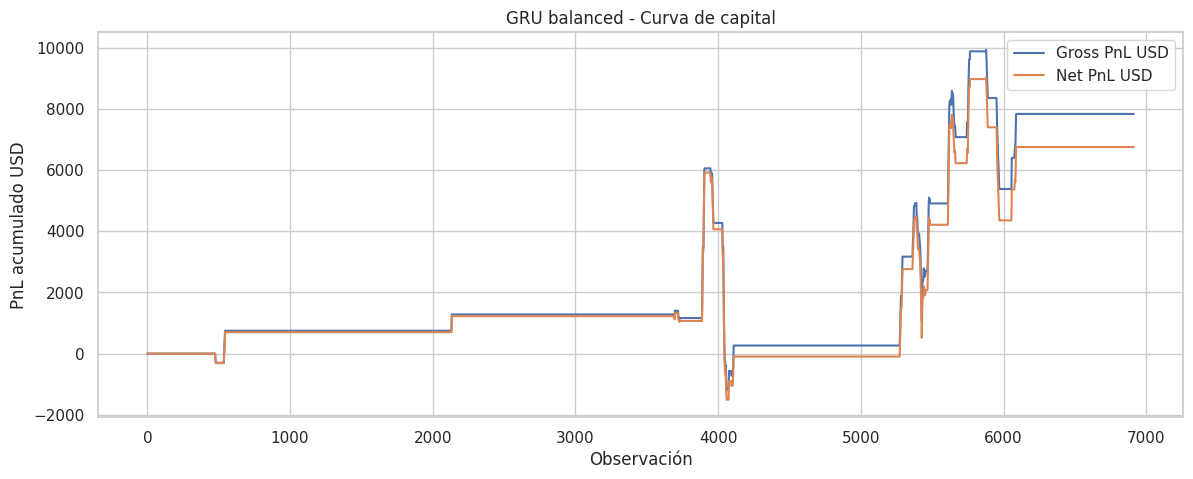

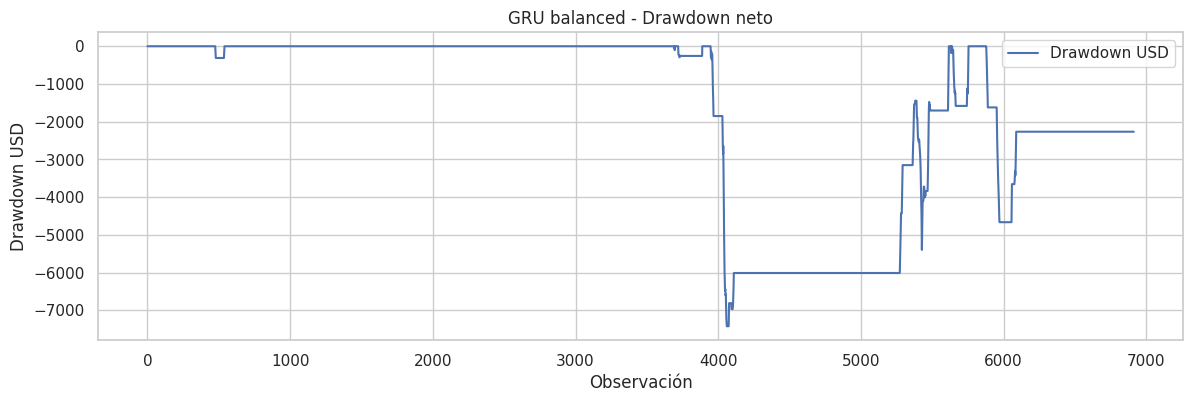

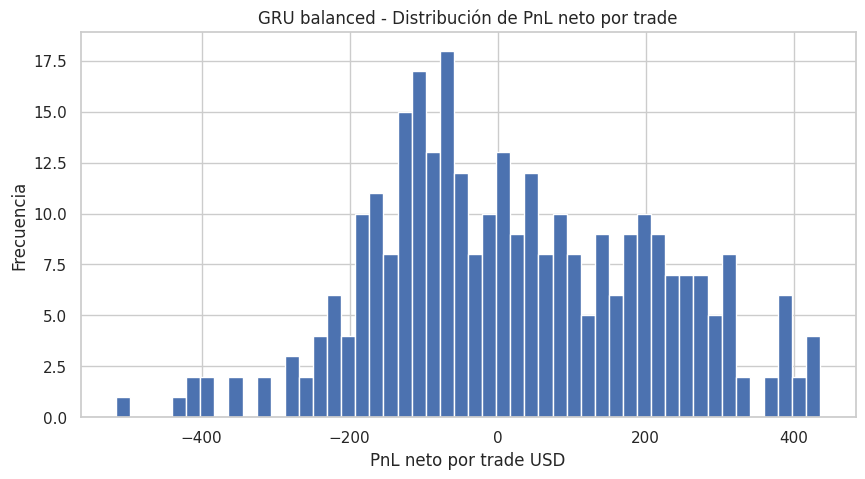

In [40]:
# =========================================================
# 14. Equity curve, drawdown y costos - GRU balanced
# =========================================================

print("=" * 80)
print("EVALUACIÓN ECONÓMICA - GRU BALANCED")
print("=" * 80)

# ---------------------------------------------------------
# 14.1. Parámetros económicos MNQ
# ---------------------------------------------------------

POINT_VALUE_USD = 2.0      # MNQ: 1 punto = 2 USD por contrato
N_CONTRACTS = 1

COMMISSION_PER_SIDE_USD = 1.25
SLIPPAGE_POINTS_PER_SIDE = 0.25

COST_PER_TRADE_USD = (
    2 * COMMISSION_PER_SIDE_USD +
    2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
) * N_CONTRACTS

print(f"Costo estimado por trade: {COST_PER_TRADE_USD:.2f} USD")


# ---------------------------------------------------------
# 14.2. Construcción de señal GRU balanced en TEST
# ---------------------------------------------------------

thr_long = 0.40
thr_short = 0.45

df_equity = df_test_gru_cmp.copy()

df_equity["signal"] = build_signal(
    df_equity,
    thr_long=thr_long,
    thr_short=thr_short,
)

df_equity["trade"] = df_equity["signal"] != 0


# ---------------------------------------------------------
# 14.3. PnL bruto y neto
# ---------------------------------------------------------

df_equity["pnl_points"] = df_equity["signal"] * df_equity["delta_30"]

df_equity["pnl_usd_gross"] = (
    df_equity["pnl_points"] * POINT_VALUE_USD * N_CONTRACTS
)

df_equity["cost_usd"] = np.where(
    df_equity["trade"],
    COST_PER_TRADE_USD,
    0.0
)

df_equity["pnl_usd_net"] = df_equity["pnl_usd_gross"] - df_equity["cost_usd"]

df_equity["cum_pnl_usd_gross"] = df_equity["pnl_usd_gross"].cumsum()
df_equity["cum_pnl_usd_net"] = df_equity["pnl_usd_net"].cumsum()


# ---------------------------------------------------------
# 14.4. Drawdown
# ---------------------------------------------------------

df_equity["equity_peak"] = df_equity["cum_pnl_usd_net"].cummax()
df_equity["drawdown_usd"] = df_equity["cum_pnl_usd_net"] - df_equity["equity_peak"]

max_drawdown_usd = df_equity["drawdown_usd"].min()


# ---------------------------------------------------------
# 14.5. Métricas económicas
# ---------------------------------------------------------

trades = df_equity[df_equity["trade"]].copy()

metrics_economic = {
    "strategy": "GRU balanced",
    "threshold_long": thr_long,
    "threshold_short": thr_short,
    "n_trades": len(trades),
    "gross_pnl_usd": trades["pnl_usd_gross"].sum(),
    "net_pnl_usd": trades["pnl_usd_net"].sum(),
    "mean_gross_pnl_usd": trades["pnl_usd_gross"].mean(),
    "mean_net_pnl_usd": trades["pnl_usd_net"].mean(),
    "win_rate_gross": (trades["pnl_usd_gross"] > 0).mean(),
    "win_rate_net": (trades["pnl_usd_net"] > 0).mean(),
    "max_drawdown_usd": max_drawdown_usd,
    "profit_factor_gross": (
        trades.loc[trades["pnl_usd_gross"] > 0, "pnl_usd_gross"].sum()
        / abs(trades.loc[trades["pnl_usd_gross"] < 0, "pnl_usd_gross"].sum())
    ),
    "profit_factor_net": (
        trades.loc[trades["pnl_usd_net"] > 0, "pnl_usd_net"].sum()
        / abs(trades.loc[trades["pnl_usd_net"] < 0, "pnl_usd_net"].sum())
    ),
}

df_metrics_economic = pd.DataFrame([metrics_economic])

print("=" * 80)
print("MÉTRICAS ECONÓMICAS")
print("=" * 80)

display(df_metrics_economic)


# ---------------------------------------------------------
# 14.6. Curva de equity
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(df_equity["cum_pnl_usd_gross"], label="Gross PnL USD")
plt.plot(df_equity["cum_pnl_usd_net"], label="Net PnL USD")
plt.title("GRU balanced - Curva de capital")
plt.xlabel("Observación")
plt.ylabel("PnL acumulado USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14.7. Drawdown
# ---------------------------------------------------------

plt.figure(figsize=(14, 4))
plt.plot(df_equity["drawdown_usd"], label="Drawdown USD")
plt.title("GRU balanced - Drawdown neto")
plt.xlabel("Observación")
plt.ylabel("Drawdown USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14.8. Distribución de PnL por trade
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(trades["pnl_usd_net"], bins=50)
plt.title("GRU balanced - Distribución de PnL neto por trade")
plt.xlabel("PnL neto por trade USD")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

## **Observación**

**Curva de capital (evolución del dinero en el tiempo)**

La curva de capital representa cómo va creciendo o cayendo el dinero a lo largo del tiempo al aplicar la estrategia.

En este caso, la curva muestra un crecimiento positivo, pero no es suave ni constante. Se observan subidas en forma de saltos, seguidas de periodos largos donde el resultado no cambia.

Esto significa que el sistema no genera ganancias de forma continua, sino que depende de momentos específicos donde ocurren varias operaciones exitosas juntas.

En términos simples, el sistema no está “trabajando todo el tiempo”, sino que aprovecha ciertas oportunidades puntuales del mercado.

---

**Drawdown (caídas desde el máximo)**

El drawdown es la caída desde un máximo previo del capital. Es decir, cuánto dinero se pierde desde un punto alto antes de volver a recuperarse.

En este caso, el drawdown máximo es cercano a -7000 USD, lo cual es significativo.

Además, esta caída ocurre de forma concentrada en un periodo específico, no de manera gradual. Esto indica que el sistema puede sufrir pérdidas fuertes en poco tiempo.

Aunque el sistema es rentable en general, este tipo de caídas implica un nivel de riesgo elevado.

---

**Distribución de resultados por operación**

La distribución muestra cuánto se gana o pierde en cada operación individual.

Se observa que:

* existen pérdidas importantes (por ejemplo, cercanas a -400 USD)
* también existen ganancias importantes (cercanas a +400 USD)

Esto indica que el sistema no gana por acertar muchas veces, sino por el tamaño de sus ganancias cuando acierta.

En otras palabras, puede perder varias veces, pero cuando gana, lo hace con mayor magnitud.

A esto se le llama “asimetría”: las ganancias son mayores que las pérdidas, aunque no necesariamente más frecuentes.

---

**Lectura global**

El sistema presenta características positivas y negativas:

Aspectos positivos:

* el resultado total es positivo, lo que indica que el sistema tiene ventaja (es decir, genera más ganancias que pérdidas en el largo plazo)
* algunas operaciones generan ganancias significativas

Aspectos negativos:

* las caídas (drawdowns) son grandes
* el resultado depende de ciertos periodos específicos de buen desempeño

---

**Problema principal**

El principal problema no está en el modelo en sí, sino en la falta de control del riesgo.

Actualmente:

* todas las operaciones tienen el mismo tamaño
* no existe un límite claro de pérdida
* no se filtran condiciones de mercado donde el modelo funciona peor

Esto hace que el sistema sea vulnerable a pérdidas grandes.

---

**Conclusión operativa**

El sistema es rentable, pero todavía no es adecuado para uso real.

Esto se debe a que:

* puede sufrir pérdidas importantes en poco tiempo
* el crecimiento del capital no es estable

Para que sea operable, es necesario reducir el riesgo y mejorar la estabilidad.

---

**Siguiente paso**

A partir de este punto, el enfoque debe cambiar.

Ya no es necesario seguir ajustando modelos o parámetros. El foco debe estar en mejorar la forma en que se gestionan las operaciones.

Los próximos pasos recomendados son:

1. Filtrar operaciones de menor calidad
   (por ejemplo, usando el nivel de confianza del modelo)

2. Ajustar el tamaño de las posiciones
   (no operar siempre con la misma exposición)

3. Analizar el desempeño según condiciones de mercado
   (para identificar cuándo el modelo funciona mejor o peor)

4. Incorporar mecanismos de control de pérdidas

Este análisis permitirá entender en qué situaciones el sistema falla y cómo hacerlo más robusto.


# **15. Optimización operativa y gestión de riesgo**

En este punto se aborda la etapa final del desarrollo del sistema, donde el foco deja de estar en el modelo predictivo y pasa a centrarse en su aplicación práctica en un entorno de trading real. Aunque el modelo ha demostrado ser rentable, el análisis previo evidencia problemas de estabilidad y control del riesgo, lo que impide su uso operativo directo.

El objetivo de esta etapa es transformar una estrategia rentable en una estrategia operable, mediante la mejora de la calidad de las señales, la adaptación al contexto de mercado y la incorporación de mecanismos de control de exposición y pérdidas.

En otras palabras, se busca no solo generar beneficios, sino hacerlo de forma consistente y controlada.

**Resumen de subpuntos**

15.1 Análisis por contexto de mercado

En este subpunto se analiza el desempeño del sistema en distintas condiciones de mercado, con el objetivo de identificar en qué situaciones el modelo funciona correctamente y en cuáles presenta debilidades.
Esto incluye segmentaciones por tiempo, tipo de operación (long/short) y características del mercado. Es un paso fundamental para entender el origen de las pérdidas y del drawdown observado.

---

15.2 Filtro de calidad de operaciones

A partir del análisis previo, se introducen criterios para seleccionar únicamente aquellas operaciones con mayor probabilidad de éxito.
El objetivo es reducir el ruido y evitar operaciones de baja calidad, mejorando la eficiencia general del sistema sin depender de cambios en el modelo.

---

15.3 Tamaño de posición

En este subpunto se define cuánto capital asignar a cada operación.
En lugar de operar siempre con la misma cantidad, se evalúan esquemas donde el tamaño de la posición varía según la calidad de la señal o el nivel de riesgo, con el fin de optimizar el rendimiento y controlar la exposición.

---

15.4 Gestión de riesgo

Finalmente, se incorporan mecanismos para limitar las pérdidas y proteger el capital.
Esto incluye reglas como pérdidas máximas por operación, límites diarios y control de drawdown.
El objetivo es asegurar que el sistema pueda sostenerse en el tiempo, evitando pérdidas que comprometan su viabilidad operativa.

---

Este conjunto de pasos permite evolucionar desde un modelo predictivo hacia un sistema de trading robusto, enfocado no solo en generar ganancias, sino en gestionarlas de manera eficiente y controlada.


## **15.1 Análisis por contexto de mercado**

En este subpunto se analiza cómo se comporta la estrategia en diferentes condiciones del mercado, con el objetivo de identificar en qué situaciones genera ganancias y en cuáles presenta pérdidas.

El análisis no se centra en el modelo en sí, sino en el contexto en el que se ejecutan las operaciones. Esto permite detectar patrones como:

* momentos del día donde el sistema funciona mejor o peor
* diferencias entre operaciones alcistas (long) y bajistas (short)
* periodos específicos donde se concentran las pérdidas

Comprender estos factores es fundamental para explicar el drawdown observado y constituye la base para mejorar la estrategia en los siguientes pasos.

---

**Primer análisis recomendado**

  - Empezamos por algo simple y muy potente:

  **PnL por tipo de operación (long vs short)**

  Esto responde:

  > ¿El modelo pierde más en compras o en ventas?



### 15.1.1 Desempeño por tipo de operación (long vs short)

In [41]:
# =========================================================
# 15.1.1 PnL por tipo de operación (long vs short)
# =========================================================

print("=" * 80)
print("PNL POR TIPO DE OPERACIÓN")
print("=" * 80)

df_ctx = df_equity.copy()

# ---------------------------------------------------------
# Clasificación de trades
# ---------------------------------------------------------

df_trades = df_ctx[df_ctx["signal"] != 0].copy()

df_trades["trade_type"] = np.where(
    df_trades["signal"] == 1,
    "LONG",
    "SHORT"
)

# ---------------------------------------------------------
# Métricas por tipo
# ---------------------------------------------------------

results = []

for trade_type, df_group in df_trades.groupby("trade_type"):

    result = {
        "trade_type": trade_type,
        "n_trades": len(df_group),
        "mean_pnl_usd": df_group["pnl_usd_net"].mean(),
        "total_pnl_usd": df_group["pnl_usd_net"].sum(),
        "win_rate": (df_group["pnl_usd_net"] > 0).mean(),
    }

    results.append(result)

df_pnl_by_type = pd.DataFrame(results)

print("=" * 80)
print("RESULTADOS")
print("=" * 80)

display(df_pnl_by_type)

PNL POR TIPO DE OPERACIÓN
RESULTADOS


,trade_type,n_trades,mean_pnl_usd,total_pnl_usd,win_rate
0,LONG,245,14.267347,3495.5,0.493878
1,SHORT,64,50.882812,3256.5,0.578125


**Observaciones**

Las operaciones **long (compra)** y **short (venta)** muestran comportamientos muy distintos.

Las operaciones **long**:

* representan la mayor parte de las operaciones (245 de 309)
* generan un beneficio total ligeramente mayor (~3495 USD)
* pero tienen menor calidad:

  * menor ganancia promedio por operación (~14 USD)
  * menor tasa de acierto (~49%)

Esto indica que el modelo opera más frecuentemente en dirección long, pero con señales de menor calidad.

---

Las operaciones **short**:

* son muchas menos (64 operaciones)
* generan un beneficio total similar (~3256 USD)
* pero con una calidad significativamente superior:

  * ganancia promedio mucho mayor (~50 USD por trade)
  * mayor tasa de acierto (~57%)

Esto indica que el modelo es mucho más preciso y efectivo cuando identifica oportunidades bajistas.

---

Interpretación

El modelo no es simétrico:

* en long: opera más, pero con menor calidad
* en short: opera menos, pero con mayor precisión y mayor retorno por operación

En términos prácticos:

```text
las operaciones short son más valiosas que las long
```

---

Conclusión

Una parte importante del rendimiento del sistema proviene de las operaciones short, a pesar de que son minoría.

Esto abre una línea clara de mejora:

* el modelo parece identificar mejor escenarios de caída que de subida
* las operaciones long están diluyendo la calidad del sistema



### 15.1.2 Desempeño intra-hora dentro del opening

En este punto se analiza cómo se comporta la estrategia dentro de la hora de apertura.
Aunque el modelo opera solo en el régimen opening, no todos los minutos de esa hora tienen la misma dinámica.
El objetivo es identificar si las ganancias o pérdidas se concentran en tramos específicos.

DESEMPEÑO INTRA-HORA DENTRO DEL OPENING
RESULTADOS POR TRAMO DEL OPENING


,opening_bin,n_trades,mean_pnl_usd,total_pnl_usd,win_rate
0,09:30-09:40,0,NaN,0.0,NaN
1,09:40-09:50,0,NaN,0.0,NaN
2,09:50-10:00,8,-79.062500,-632.5,0.375000
3,10:00-10:10,93,25.032258,2328.0,0.548387
4,10:10-10:20,119,57.046218,6788.5,0.596639
5,10:20-10:30,89,-19.460674,-1732.0,0.370787


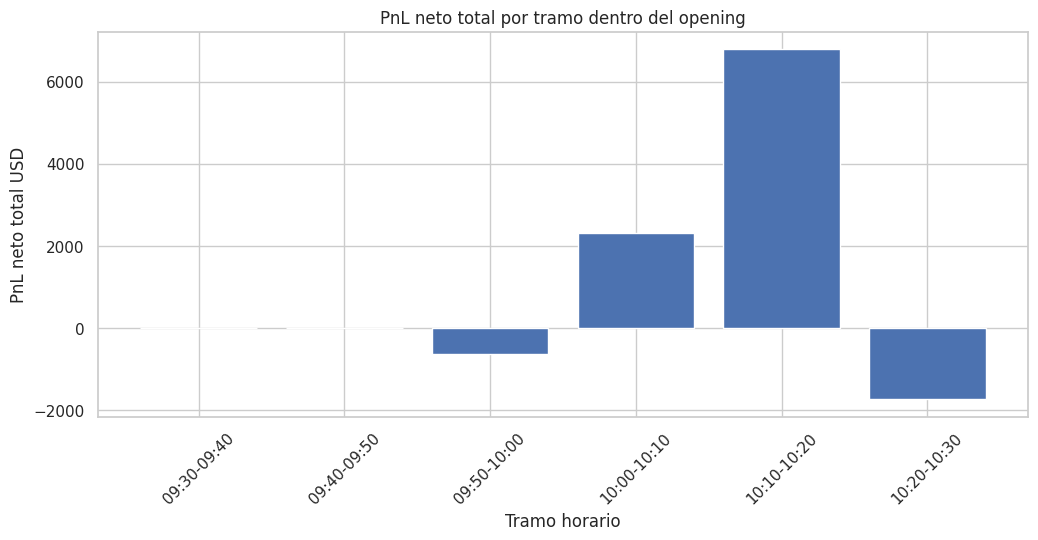

In [42]:
# =========================================================
# 15.1.2. Desempeño intra-hora dentro del opening
# =========================================================

print("=" * 80)
print("DESEMPEÑO INTRA-HORA DENTRO DEL OPENING")
print("=" * 80)

df_ctx = df_equity.copy()

# ---------------------------------------------------------
# 1. Filtrar solo trades
# ---------------------------------------------------------

df_trades = df_ctx[df_ctx["signal"] != 0].copy()

# ---------------------------------------------------------
# 2. Crear bins de 10 minutos dentro del opening
# ---------------------------------------------------------
# Se asume que minute_of_day está expresado como minuto absoluto del día.
# 09:30 = 570
# 10:30 = 630

bins = [570, 580, 590, 600, 610, 620, 630]
labels = [
    "09:30-09:40",
    "09:40-09:50",
    "09:50-10:00",
    "10:00-10:10",
    "10:10-10:20",
    "10:20-10:30",
]

df_trades["opening_bin"] = pd.cut(
    df_trades["minute_of_day"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

# ---------------------------------------------------------
# 3. Métricas por tramo intra-hora
# ---------------------------------------------------------

df_pnl_by_bin = (
    df_trades
    .groupby("opening_bin", observed=False)
    .agg(
        n_trades=("pnl_usd_net", "count"),
        mean_pnl_usd=("pnl_usd_net", "mean"),
        total_pnl_usd=("pnl_usd_net", "sum"),
        win_rate=("pnl_usd_net", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

print("=" * 80)
print("RESULTADOS POR TRAMO DEL OPENING")
print("=" * 80)

display(df_pnl_by_bin)

# ---------------------------------------------------------
# 4. Visualización simple del PnL total por tramo
# ---------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.bar(df_pnl_by_bin["opening_bin"].astype(str), df_pnl_by_bin["total_pnl_usd"])
plt.title("PnL neto total por tramo dentro del opening")
plt.xlabel("Tramo horario")
plt.ylabel("PnL neto total USD")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Observaciones**

No hay actividad en los primeros 20 minutos (09:30–09:50).
El sistema no genera operaciones en ese tramo, lo que indica que los thresholds actuales filtran completamente esa fase inicial.

El tramo 09:50–10:00 presenta pérdidas.
Tiene pocas operaciones, bajo porcentaje de acierto (37%) y resultado negativo. Es una zona de baja calidad.

El tramo 10:00–10:20 concentra el rendimiento positivo.
En particular:

* 10:00–10:10: buen desempeño, positivo y relativamente estable
* 10:10–10:20: el mejor tramo, mayor PnL total, mayor promedio por trade y mejor tasa de acierto (~60%)

En este rango se encuentra el núcleo del desempeño del sistema.

El tramo 10:20–10:30 vuelve a ser negativo.
A pesar de tener muchas operaciones, presenta:

* pérdida total significativa
* bajo porcentaje de acierto (~37%)

Esto indica que el modelo pierde efectividad hacia el final del opening.

---

Conclusión

El rendimiento del sistema está claramente concentrado en una ventana específica:

10:00 – 10:20

Fuera de ese rango:

* antes: no opera o presenta pérdidas
* después: presenta pérdidas

---

Implicación directa

El drawdown observado proviene principalmente de:

* operaciones en 09:50–10:00
* operaciones en 10:20–10:30

---

Siguiente paso lógico

Esto permite definir una mejora inmediata:

restringir la operativa a la ventana:

10:00 – 10:20

Antes de aplicar filtros más complejos, este ajuste puede:

* eliminar operaciones de baja calidad
* reducir el drawdown
* mejorar la estabilidad del sistema


# Análisis ajustado a 10:00 a 10:20

CÁLCULO DE PnL - GRU
Costo estimado por trade: 3.50 USD
RESULTADOS PnL - SIN FILTRO vs FILTRO TEMPORAL


,strategy,filter,threshold_long,threshold_short,n_trades,mean_pnl_points,total_pnl_points,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net
0,balanced,10:00_10:20,0.40,0.45,212,23.251179,4929.25,9858.5,9116.5,46.502358,43.002358,0.575472,0.575472
1,balanced,sin_filtro,0.40,0.45,309,12.675566,3916.75,7833.5,6752.0,25.351133,21.851133,0.514563,0.511327
2,baseline,10:00_10:20,0.40,0.40,642,4.621106,2966.75,5933.5,3686.5,9.242212,5.742212,0.485981,0.482866
3,conservative,10:00_10:20,0.41,0.50,120,8.954167,1074.50,2149.0,1729.0,17.908333,14.408333,0.500000,0.500000
4,high_precision,10:00_10:20,0.41,0.56,120,8.954167,1074.50,2149.0,1729.0,17.908333,14.408333,0.500000,0.500000
5,baseline,sin_filtro,0.40,0.40,916,2.474072,2266.25,4532.5,1326.5,4.948144,1.448144,0.465066,0.459607
6,high_precision,sin_filtro,0.41,0.56,188,1.686170,317.00,634.0,-24.0,3.372340,-0.127660,0.462766,0.457447
7,conservative,sin_filtro,0.41,0.50,188,1.686170,317.00,634.0,-24.0,3.372340,-0.127660,0.462766,0.457447


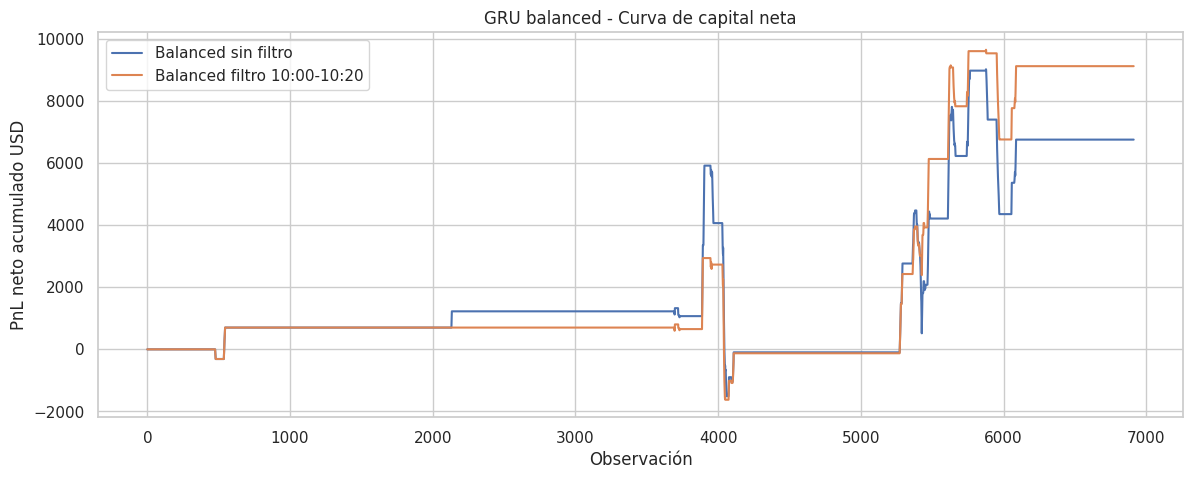

In [43]:
# =========================================================
# 13. Cálculo de PnL - GRU configuraciones
#     con y sin filtro temporal intra-opening
# =========================================================

print("=" * 80)
print("CÁLCULO DE PnL - GRU")
print("=" * 80)

# =========================================================
# 13.1. Parámetros económicos
# =========================================================

POINT_VALUE_USD = 2.0      # MNQ: 1 punto = 2 USD por contrato
N_CONTRACTS = 1

COMMISSION_PER_SIDE_USD = 1.25
SLIPPAGE_POINTS_PER_SIDE = 0.25

COST_PER_TRADE_USD = (
    2 * COMMISSION_PER_SIDE_USD +
    2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
) * N_CONTRACTS

print(f"Costo estimado por trade: {COST_PER_TRADE_USD:.2f} USD")


# =========================================================
# 13.2. Función para construir señales
# =========================================================

def build_signal(df, thr_long, thr_short):
    """
    Genera señal operativa:
        1  = long
       -1  = short
        0  = no trade
    """

    p_long = df["gru_proba_1"].values
    p_short = df["gru_proba_-1"].values

    signal = np.zeros(len(df), dtype=int)

    long_mask = p_long >= thr_long
    short_mask = p_short >= thr_short

    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    conflict = long_mask & short_mask
    signal[conflict & (p_long > p_short)] = 1
    signal[conflict & (p_short > p_long)] = -1

    return signal


# =========================================================
# 13.3. Función para calcular PnL
# =========================================================

def compute_pnl_metrics(df, signal_col, strategy_name):
    """
    Calcula métricas económicas usando:
        pnl_points = signal * delta_30
        pnl_usd_gross = pnl_points * valor del punto
        pnl_usd_net = pnl_usd_gross - costos por trade
    """

    tmp = df.copy()

    tmp["trade"] = tmp[signal_col] != 0

    tmp["pnl_points"] = tmp[signal_col] * tmp["delta_30"]

    tmp["pnl_usd_gross"] = (
        tmp["pnl_points"] * POINT_VALUE_USD * N_CONTRACTS
    )

    tmp["cost_usd"] = np.where(
        tmp["trade"],
        COST_PER_TRADE_USD,
        0.0
    )

    tmp["pnl_usd_net"] = tmp["pnl_usd_gross"] - tmp["cost_usd"]

    tmp["cum_pnl_usd_gross"] = tmp["pnl_usd_gross"].cumsum()
    tmp["cum_pnl_usd_net"] = tmp["pnl_usd_net"].cumsum()

    trades = tmp[tmp["trade"]].copy()

    if len(trades) == 0:
        return tmp, {
            "strategy": strategy_name,
            "n_trades": 0,
            "mean_pnl_points": np.nan,
            "total_pnl_points": 0.0,
            "gross_pnl_usd": 0.0,
            "net_pnl_usd": 0.0,
            "mean_gross_pnl_usd": np.nan,
            "mean_net_pnl_usd": np.nan,
            "win_rate_gross": np.nan,
            "win_rate_net": np.nan,
        }

    metrics = {
        "strategy": strategy_name,
        "n_trades": len(trades),
        "mean_pnl_points": trades["pnl_points"].mean(),
        "total_pnl_points": trades["pnl_points"].sum(),
        "gross_pnl_usd": trades["pnl_usd_gross"].sum(),
        "net_pnl_usd": trades["pnl_usd_net"].sum(),
        "mean_gross_pnl_usd": trades["pnl_usd_gross"].mean(),
        "mean_net_pnl_usd": trades["pnl_usd_net"].mean(),
        "win_rate_gross": (trades["pnl_usd_gross"] > 0).mean(),
        "win_rate_net": (trades["pnl_usd_net"] > 0).mean(),
    }

    return tmp, metrics


# =========================================================
# 13.4. Configuraciones GRU a evaluar
# =========================================================

configs = [
    ("baseline", 0.40, 0.40),
    ("balanced", 0.40, 0.45),
    ("conservative", 0.41, 0.50),
    ("high_precision", 0.41, 0.56),
]


# =========================================================
# 13.5. Evaluación sin filtro temporal
# =========================================================

results_no_filter = []
equity_curves = {}

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal"] = build_signal(
        df=df_tmp,
        thr_long=thr_l,
        thr_short=thr_s,
    )

    df_pnl_tmp, metrics = compute_pnl_metrics(
        df=df_tmp,
        signal_col="signal",
        strategy_name=name,
    )

    metrics["filter"] = "sin_filtro"
    metrics["threshold_long"] = thr_l
    metrics["threshold_short"] = thr_s

    results_no_filter.append(metrics)
    equity_curves[(name, "sin_filtro")] = df_pnl_tmp


# =========================================================
# 13.6. Evaluación con filtro temporal 10:00-10:20
# =========================================================

results_time_filter = []

TIME_START = 600   # 10:00
TIME_END = 620     # 10:20

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal_raw_strategy"] = build_signal(
        df=df_tmp,
        thr_long=thr_l,
        thr_short=thr_s,
    )

    valid_time_mask = (
        (df_tmp["minute_of_day"] >= TIME_START) &
        (df_tmp["minute_of_day"] < TIME_END)
    )

    # No se eliminan filas: solo se anulan señales fuera del rango horario
    df_tmp["signal_time_filter"] = np.where(
        valid_time_mask,
        df_tmp["signal_raw_strategy"],
        0
    )

    df_pnl_tmp, metrics = compute_pnl_metrics(
        df=df_tmp,
        signal_col="signal_time_filter",
        strategy_name=name,
    )

    metrics["filter"] = "10:00_10:20"
    metrics["threshold_long"] = thr_l
    metrics["threshold_short"] = thr_s

    results_time_filter.append(metrics)
    equity_curves[(name, "10:00_10:20")] = df_pnl_tmp


# =========================================================
# 13.7. Resultados comparativos
# =========================================================

df_pnl_comparison = pd.DataFrame(
    results_no_filter + results_time_filter
)

df_pnl_comparison = df_pnl_comparison[
    [
        "strategy",
        "filter",
        "threshold_long",
        "threshold_short",
        "n_trades",
        "mean_pnl_points",
        "total_pnl_points",
        "gross_pnl_usd",
        "net_pnl_usd",
        "mean_gross_pnl_usd",
        "mean_net_pnl_usd",
        "win_rate_gross",
        "win_rate_net",
    ]
].sort_values(
    by="net_pnl_usd",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("RESULTADOS PnL - SIN FILTRO vs FILTRO TEMPORAL")
print("=" * 80)

display(df_pnl_comparison)


# =========================================================
# 13.8. Curva de capital para GRU balanced
# =========================================================

df_balanced_no_filter = equity_curves[("balanced", "sin_filtro")]
df_balanced_time_filter = equity_curves[("balanced", "10:00_10:20")]

plt.figure(figsize=(14, 5))

plt.plot(
    df_balanced_no_filter["cum_pnl_usd_net"].values,
    label="Balanced sin filtro"
)

plt.plot(
    df_balanced_time_filter["cum_pnl_usd_net"].values,
    label="Balanced filtro 10:00-10:20"
)

plt.title("GRU balanced - Curva de capital neta")
plt.xlabel("Observación")
plt.ylabel("PnL neto acumulado USD")
plt.legend()
plt.grid(True)
plt.show()